# Figure 1B PTEN-PI3KCB Graph

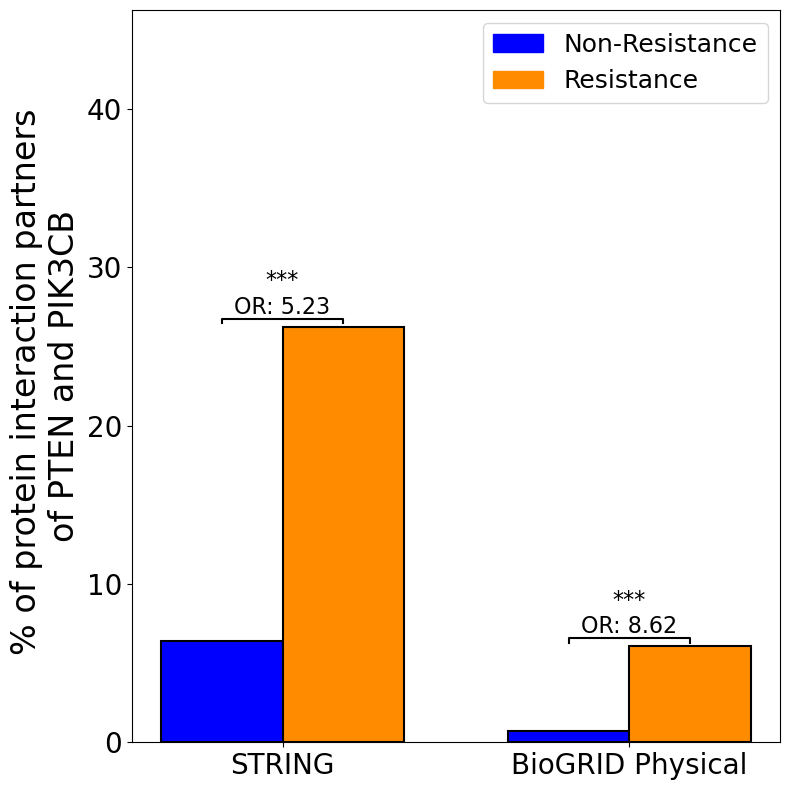

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import fisher_exact


string_count = pd.read_csv('results/2_interaction_overlap/string_counts/dunn_PTEN_PIK3CB_string_count.csv')
biogrid_count = pd.read_csv('results/2_interaction_overlap/biogrid_counts/dunn_PTEN_PIK3CB_biogrid_count.csv')

interacted_resistant_string = string_count['Interacted'][3]+string_count['Interacted'][2]+string_count['Interacted'][1]
interacted_no_resistant_string = string_count['Interacted'][0]
no_interacted_resistant_string = (string_count['Total'][3]+string_count['Total'][2]+string_count['Total'][1])- interacted_resistant_string
no_interacted_no_resistant_string = string_count['Total'][0] - string_count['Interacted'][0]

contingency_table_string = [[interacted_resistant_string, interacted_no_resistant_string],[no_interacted_resistant_string, no_interacted_no_resistant_string]]
contingency_table_string

odds_ratio_string, p_value_string = fisher_exact(contingency_table_string)


interacted_resistant_biogrid = biogrid_count['Interacted'][3]+biogrid_count['Interacted'][2]+biogrid_count['Interacted'][1]
interacted_no_resistant_biogrid = biogrid_count['Interacted'][0]
no_interacted_resistant_biogrid = (biogrid_count['Total'][3]+biogrid_count['Total'][2]+biogrid_count['Total'][1])- interacted_resistant_biogrid
no_interacted_no_resistant_biogrid = biogrid_count['Total'][0] - biogrid_count['Interacted'][0]

contingency_table_biogrid = [[interacted_resistant_biogrid, interacted_no_resistant_biogrid],
                             [no_interacted_resistant_biogrid, no_interacted_no_resistant_biogrid]]
contingency_table_biogrid

odds_ratio_biogrid, p_value_biogrid = fisher_exact(contingency_table_biogrid)


# Calculate the percentage for both graphs
string_count_resistant_percentage = ((string_count['Interacted'][3]+string_count['Interacted'][2]+string_count['Interacted'][1]) / (string_count['Total'][3]+string_count['Total'][2]+string_count['Total'][1])) * 100
string_count_not_resistant_percentage = (string_count['Interacted'][0]/ string_count['Total'][0]) * 100
biogrid_count_resistant_percentage = ((biogrid_count['Interacted'][3]+biogrid_count['Interacted'][2]+biogrid_count['Interacted'][1]) / (biogrid_count['Total'][3]+biogrid_count['Total'][2]+biogrid_count['Total'][1])) * 100
biogrid_count_not_resistant_percentage = (biogrid_count['Interacted'][0]/ biogrid_count['Total'][0]) * 100

# Define the positions for the bars
bar_width = 0.35  # Width of the bars
bar_positions_1 = np.array([0, 0.35])  # Positions for STRING
bar_positions_2 = np.array([1, 1.35])  # Positions for BIOGRID

# Create the plot
plt.figure(figsize=(8, 8))

# Plot Non-Resistant and Resistant bars for STRING
plt.bar(bar_positions_1[0], string_count_not_resistant_percentage, width=bar_width, color='blue', edgecolor='black', linewidth=1.5)
plt.bar(bar_positions_1[1], string_count_resistant_percentage, width=bar_width, color='darkorange', edgecolor='black', linewidth=1.5)


# Plot Non-Resistant and Resistant bars for BIOGRID
plt.bar(bar_positions_2[0], biogrid_count_not_resistant_percentage, width=bar_width, color='blue', edgecolor='black', linewidth=1.5)
plt.bar(bar_positions_2[1], biogrid_count_resistant_percentage, width=bar_width, color='darkorange', edgecolor='black', linewidth=1.5)

# Add labels and title
plt.ylabel('% of protein interaction partners \nof PTEN and PIK3CB', fontsize=24)
plt.ylim(0, max(string_count_resistant_percentage, biogrid_count_resistant_percentage) + 20)

# Change x-axis labels to gene pair names
plt.xticks(ticks=[0.175, 1.175], labels=['STRING', 'BioGRID Physical'], fontsize=20)
plt.yticks(fontsize=20)

# Helper function to get significance stars
def significance_stars(pval):
    if pval < 0.001:
        return "***"
    elif pval < 0.01:
        return "**"
    elif pval < 0.05:
        return "*"
    else:
        return "n.s."

# STRING annotation
y_max_1 = string_count_resistant_percentage
y_1 = y_max_1 + 0.5
plt.plot([bar_positions_1[0], bar_positions_1[0], bar_positions_1[1], bar_positions_1[1]], 
         [y_1 - 0.3, y_1, y_1, y_1 - 0.3], lw=1.5, c='k')

plt.text(np.mean([bar_positions_1[0], bar_positions_1[1]]), y_1, 
         f'{significance_stars(p_value_string)}\nOR: {odds_ratio_string:.2f}', 
         ha='center', va='bottom', color='k', fontsize=16)

# BIOGRID annotation
y_max_2 = biogrid_count_resistant_percentage
y_2 = y_max_2 + 0.5
plt.plot([bar_positions_2[0], bar_positions_2[0], bar_positions_2[1], bar_positions_2[1]], 
         [y_2 - 0.3, y_2, y_2, y_2 - 0.3], lw=1.5, c='k')

plt.text(np.mean([bar_positions_2[0], bar_positions_2[1]]), y_2, 
         f'{significance_stars(p_value_biogrid)}\nOR: {odds_ratio_biogrid:.2f}', 
         ha='center', va='bottom', color='k', fontsize=16)

# Create a custom legend
plt.legend(['Non-Resistance', 'Resistance'], title="Resistance Status", loc='upper right')

# Manually assign legend colors
handles = [plt.Rectangle((0, 0), 1, 1, color='blue'),
           plt.Rectangle((0, 0), 1, 1, color='darkorange')]
labels = ['Non-Resistance', 'Resistance']
plt.legend(handles, labels, fontsize=18)

# Save and show the plot
plt.tight_layout()
plt.savefig('results/3_interaction_overlap_graphs/figure1b_pten_pi3kcb_graph_with_asterisk.jpg',dpi=600)
plt.show()

# Figure 2B-Total Analysis of all screen with no duplicates

In [2]:
import pandas as pd
# Load all datasets into a dictionary
datasets = {
    "dunn_pten_pik3cb": pd.read_csv('results/2_interaction_overlap/string_results/dunn_PTEN_PIK3CB_string_results.csv'),
    "dunn_pten_akt": pd.read_csv('results/2_interaction_overlap/string_results/dunn_PTEN_AKT_string_results.csv'),
    "llorca_awwad_arid1a_atr": pd.read_csv('results/2_interaction_overlap/string_results/ARID1A_ATR_Awwad_Llorca_aggregated_string_results.csv'),
    "krall_wang_yu_kras_mek": pd.read_csv('results/2_interaction_overlap/string_results/KRAS_MEK_Krall_Wang_Yu_aggregated_string_results.csv'),
    "noordermeer_zimmermann_brca1_parp1": pd.read_csv('results/2_interaction_overlap/string_results/BRCA1_PARP1_Noordermeer_Zimmermann_aggregated_string_results.csv'),
    "hayes_krall_nras_mek": pd.read_csv('results/2_interaction_overlap/string_results/NRAS_MEK_Hayes_Krall_aggregated_string_results.csv'),
    "hayes_nras_cdk46": pd.read_csv('results/2_interaction_overlap/string_results/hayes_NRAS_CDK4_6_string_results.csv'),
    "krall_braf_mek": pd.read_csv('results/2_interaction_overlap/string_results/krall_BRAF_MEK_string_results.csv')}

# Process each dataframe to add "Resistant" column
for name, df in datasets.items():
    # Add dataset name column
    df["Dataset"] = name


# Merge all DataFrames into a single DataFrame
merged_screen = pd.concat(datasets.values(), ignore_index=True)
merged_screen['Resistance'] = merged_screen['Resistance'].replace({"Not_Resistant": "NotResistant"})

merged_screen

,Cell_line,Resistance,Gene,Gene_corrected,hgnc_id,ensembl_gene_id,entrez_id,Interaction_Partners,Dataset
0,3 cell line,Resistant,PIK3R2,PIK3R2,HGNC:8980,ENSG00000105647,5296.0,Partner,dunn_pten_pik3cb
1,NaN,Resistant,INPPL1,INPPL1,HGNC:6080,ENSG00000165458,3636.0,Partner,dunn_pten_pik3cb
2,NaN,Resistant,TSC2,TSC2,HGNC:12363,ENSG00000103197,7249.0,Partner,dunn_pten_pik3cb
3,2 cell line,Resistant,NF2,NF2,HGNC:7773,ENSG00000186575,4771.0,Partner,dunn_pten_pik3cb
4,NaN,Resistant,CXorf56,CXorf56,HGNC:26239,ENSG00000018610,63932.0,Not partner,dunn_pten_pik3cb
...,...,...,...,...,...,...,...,...,...
144075,NaN,NotResistant,HSPE1-MOB4,HSPE1-MOB4,HGNC:49184,ENSG00000270757,100529241.0,Not partner,krall_braf_mek
144076,NaN,NotResistant,BAGE3,BAGE3,HGNC:15728,NaN,85318.0,Not partner,krall_braf_mek
144077,NaN,NotResistant,HIST2H3A,HIST2H3A,HGNC:20505,ENSG00000203852,333932.0,Not partner,krall_braf_mek
144078,NaN,NotResistant,RPL17,RPL17,HGNC:10307,ENSG00000265681,6139.0,Not partner,krall_braf_mek


In [3]:
resistant_rows = merged_screen[merged_screen["Resistance"] == "Resistant"]

resistant_rows.reset_index(inplace=True,drop=True)
resistant_rows


,Cell_line,Resistance,Gene,Gene_corrected,hgnc_id,ensembl_gene_id,entrez_id,Interaction_Partners,Dataset
0,3 cell line,Resistant,PIK3R2,PIK3R2,HGNC:8980,ENSG00000105647,5296.0,Partner,dunn_pten_pik3cb
1,NaN,Resistant,INPPL1,INPPL1,HGNC:6080,ENSG00000165458,3636.0,Partner,dunn_pten_pik3cb
2,NaN,Resistant,TSC2,TSC2,HGNC:12363,ENSG00000103197,7249.0,Partner,dunn_pten_pik3cb
3,2 cell line,Resistant,NF2,NF2,HGNC:7773,ENSG00000186575,4771.0,Partner,dunn_pten_pik3cb
4,NaN,Resistant,CXorf56,CXorf56,HGNC:26239,ENSG00000018610,63932.0,Not partner,dunn_pten_pik3cb
...,...,...,...,...,...,...,...,...,...
1619,NaN,Resistant,IL4,IL4,HGNC:6014,ENSG00000113520,3565.0,Not partner,krall_braf_mek
1620,NaN,Resistant,ZSCAN22,ZSCAN22,HGNC:4929,ENSG00000182318,342945.0,Not partner,krall_braf_mek
1621,NaN,Resistant,FZR1,FZR1,HGNC:24824,ENSG00000105325,51343.0,Partner,krall_braf_mek
1622,NaN,Resistant,ZNF708,ZNF708,HGNC:12945,ENSG00000182141,7562.0,Not partner,krall_braf_mek


In [4]:
not_resistant_rows = merged_screen[merged_screen["Resistance"] == "NotResistant"]
not_resistant_rows.reset_index(inplace=True,drop=True)
not_resistant_rows

,Cell_line,Resistance,Gene,Gene_corrected,hgnc_id,ensembl_gene_id,entrez_id,Interaction_Partners,Dataset
0,0 cell line,NotResistant,A1BG,A1BG,HGNC:5,ENSG00000121410,1.0,Not partner,dunn_pten_pik3cb
1,NaN,NotResistant,A1CF,A1CF,HGNC:24086,ENSG00000148584,29974.0,Not partner,dunn_pten_pik3cb
2,NaN,NotResistant,A2M,A2M,HGNC:7,ENSG00000175899,2.0,Not partner,dunn_pten_pik3cb
3,NaN,NotResistant,A2ML1,A2ML1,HGNC:23336,ENSG00000166535,144568.0,Not partner,dunn_pten_pik3cb
4,NaN,NotResistant,A3GALT2,A3GALT2,HGNC:30005,ENSG00000184389,127550.0,Not partner,dunn_pten_pik3cb
...,...,...,...,...,...,...,...,...,...
142451,NaN,NotResistant,HSPE1-MOB4,HSPE1-MOB4,HGNC:49184,ENSG00000270757,100529241.0,Not partner,krall_braf_mek
142452,NaN,NotResistant,BAGE3,BAGE3,HGNC:15728,NaN,85318.0,Not partner,krall_braf_mek
142453,NaN,NotResistant,HIST2H3A,HIST2H3A,HGNC:20505,ENSG00000203852,333932.0,Not partner,krall_braf_mek
142454,NaN,NotResistant,RPL17,RPL17,HGNC:10307,ENSG00000265681,6139.0,Not partner,krall_braf_mek


In [5]:
from scipy.stats import fisher_exact
interacted_resistant = resistant_rows[(resistant_rows['Interaction_Partners'] == 'Partner') & (resistant_rows['Resistance'] == 'Resistant')].shape[0]
interacted_no_resistant = not_resistant_rows[(not_resistant_rows['Interaction_Partners'] == 'Partner') & (not_resistant_rows['Resistance'] == 'NotResistant')].shape[0]
no_interacted_resistant = resistant_rows[(resistant_rows['Interaction_Partners'] == 'Not partner') & (resistant_rows['Resistance'] == 'Resistant')].shape[0]
no_interacted_no_resistant = not_resistant_rows[(not_resistant_rows['Interaction_Partners'] == 'Not partner') & (not_resistant_rows['Resistance'] == 'NotResistant')].shape[0]

contingency_table = [[interacted_resistant, interacted_no_resistant],[no_interacted_resistant, no_interacted_no_resistant]]

odds_ratio, p_value = fisher_exact(contingency_table)

resistant_ratio = (interacted_resistant / (interacted_resistant+ no_interacted_resistant)) * 100
not_resistant_ratio = (interacted_no_resistant / (interacted_no_resistant+ no_interacted_no_resistant)) * 100


string_results = pd.DataFrame([{
    "Interacted_Resistant": interacted_resistant,
    "Interacted_No_Resistant": interacted_no_resistant,
    "No_Interacted_Resistant": no_interacted_resistant,
    "No_Interacted_No_Resistant": no_interacted_no_resistant,
    "Odds_Ratio": odds_ratio,
    "P_Value": p_value,
    "Resistant_ratio": resistant_ratio,
    "Not_Resistant_ratio" : not_resistant_ratio
}])

string_results

,Interacted_Resistant,Interacted_No_Resistant,No_Interacted_Resistant,No_Interacted_No_Resistant,Odds_Ratio,P_Value,Resistant_ratio,Not_Resistant_ratio
0,239,8555,1385,133901,2.700921,4.698948e-36,14.716749,6.005363


In [6]:
import pandas as pd
# Load all datasets_2 into a dictionary
datasets_2 = {
    "dunn_pten_pik3cb": pd.read_csv('results/2_interaction_overlap/biogrid_results/dunn_PTEN_PIK3CB_biogrid_results.csv'),
    "dunn_pten_akt": pd.read_csv('results/2_interaction_overlap/biogrid_results/dunn_PTEN_AKT_biogrid_results.csv'),
    "llorca_awwad_arid1a_atr": pd.read_csv('results/2_interaction_overlap/biogrid_results/ARID1A_ATR_Awwad_Llorca_aggregated_biogrid_results.csv'),
    "krall_wang_yu_kras_mek": pd.read_csv('results/2_interaction_overlap/biogrid_results/KRAS_MEK_Krall_Wang_Yu_aggregated_biogrid_results.csv'),
    "noordermeer_zimmermann_brca1_parp1": pd.read_csv('results/2_interaction_overlap/biogrid_results/BRCA1_PARP1_Noordermeer_Zimmermann_aggregated_biogrid_results.csv'),
    "hayes_krall_nras_mek": pd.read_csv('results/2_interaction_overlap/biogrid_results/NRAS_MEK_Hayes_Krall_aggregated_biogrid_results.csv'),
    "hayes_nras_cdk46": pd.read_csv('results/2_interaction_overlap/biogrid_results/hayes_NRAS_CDK4_6_biogrid_results.csv'),
    "krall_braf_mek": pd.read_csv('results/2_interaction_overlap/biogrid_results/krall_BRAF_MEK_biogrid_results.csv')}

# Process each dataframe to add "Resistant" column
for name, df in datasets_2.items():
    # Add dataset name column
    df["Dataset"] = name

# Merge all DataFrames into a single DataFrame
merged_screen = pd.concat(datasets_2.values(), ignore_index=True)
merged_screen['Resistance'] = merged_screen['Resistance'].replace({"Not_Resistant": "NotResistant"})
merged_screen

,Cell_line,Resistance,Gene,Gene_corrected,hgnc_id,ensembl_gene_id,entrez_id,Interaction_Partners,Dataset
0,3 cell line,Resistant,PIK3R2,PIK3R2,HGNC:8980,ENSG00000105647,5296.0,Partner,dunn_pten_pik3cb
1,NaN,Resistant,INPPL1,INPPL1,HGNC:6080,ENSG00000165458,3636.0,Not partner,dunn_pten_pik3cb
2,NaN,Resistant,TSC2,TSC2,HGNC:12363,ENSG00000103197,7249.0,Not partner,dunn_pten_pik3cb
3,2 cell line,Resistant,NF2,NF2,HGNC:7773,ENSG00000186575,4771.0,Not partner,dunn_pten_pik3cb
4,NaN,Resistant,CXorf56,CXorf56,HGNC:26239,ENSG00000018610,63932.0,Not partner,dunn_pten_pik3cb
...,...,...,...,...,...,...,...,...,...
144075,NaN,NotResistant,HSPE1-MOB4,HSPE1-MOB4,HGNC:49184,ENSG00000270757,100529241.0,Not partner,krall_braf_mek
144076,NaN,NotResistant,BAGE3,BAGE3,HGNC:15728,NaN,85318.0,Not partner,krall_braf_mek
144077,NaN,NotResistant,HIST2H3A,HIST2H3A,HGNC:20505,ENSG00000203852,333932.0,Not partner,krall_braf_mek
144078,NaN,NotResistant,RPL17,RPL17,HGNC:10307,ENSG00000265681,6139.0,Not partner,krall_braf_mek


In [7]:
resistant_rows = merged_screen[merged_screen["Resistance"] == "Resistant"]

resistant_rows.reset_index(inplace=True,drop=True)
resistant_rows


,Cell_line,Resistance,Gene,Gene_corrected,hgnc_id,ensembl_gene_id,entrez_id,Interaction_Partners,Dataset
0,3 cell line,Resistant,PIK3R2,PIK3R2,HGNC:8980,ENSG00000105647,5296.0,Partner,dunn_pten_pik3cb
1,NaN,Resistant,INPPL1,INPPL1,HGNC:6080,ENSG00000165458,3636.0,Not partner,dunn_pten_pik3cb
2,NaN,Resistant,TSC2,TSC2,HGNC:12363,ENSG00000103197,7249.0,Not partner,dunn_pten_pik3cb
3,2 cell line,Resistant,NF2,NF2,HGNC:7773,ENSG00000186575,4771.0,Not partner,dunn_pten_pik3cb
4,NaN,Resistant,CXorf56,CXorf56,HGNC:26239,ENSG00000018610,63932.0,Not partner,dunn_pten_pik3cb
...,...,...,...,...,...,...,...,...,...
1619,NaN,Resistant,IL4,IL4,HGNC:6014,ENSG00000113520,3565.0,Not partner,krall_braf_mek
1620,NaN,Resistant,ZSCAN22,ZSCAN22,HGNC:4929,ENSG00000182318,342945.0,Not partner,krall_braf_mek
1621,NaN,Resistant,FZR1,FZR1,HGNC:24824,ENSG00000105325,51343.0,Not partner,krall_braf_mek
1622,NaN,Resistant,ZNF708,ZNF708,HGNC:12945,ENSG00000182141,7562.0,Not partner,krall_braf_mek


In [8]:
not_resistant_rows = merged_screen[merged_screen["Resistance"] == "NotResistant"]
not_resistant_rows.reset_index(inplace=True,drop=True)
not_resistant_rows

,Cell_line,Resistance,Gene,Gene_corrected,hgnc_id,ensembl_gene_id,entrez_id,Interaction_Partners,Dataset
0,0 cell line,NotResistant,A1BG,A1BG,HGNC:5,ENSG00000121410,1.0,Not partner,dunn_pten_pik3cb
1,NaN,NotResistant,A1CF,A1CF,HGNC:24086,ENSG00000148584,29974.0,Not partner,dunn_pten_pik3cb
2,NaN,NotResistant,A2M,A2M,HGNC:7,ENSG00000175899,2.0,Not partner,dunn_pten_pik3cb
3,NaN,NotResistant,A2ML1,A2ML1,HGNC:23336,ENSG00000166535,144568.0,Not partner,dunn_pten_pik3cb
4,NaN,NotResistant,A3GALT2,A3GALT2,HGNC:30005,ENSG00000184389,127550.0,Not partner,dunn_pten_pik3cb
...,...,...,...,...,...,...,...,...,...
142451,NaN,NotResistant,HSPE1-MOB4,HSPE1-MOB4,HGNC:49184,ENSG00000270757,100529241.0,Not partner,krall_braf_mek
142452,NaN,NotResistant,BAGE3,BAGE3,HGNC:15728,NaN,85318.0,Not partner,krall_braf_mek
142453,NaN,NotResistant,HIST2H3A,HIST2H3A,HGNC:20505,ENSG00000203852,333932.0,Not partner,krall_braf_mek
142454,NaN,NotResistant,RPL17,RPL17,HGNC:10307,ENSG00000265681,6139.0,Not partner,krall_braf_mek


In [9]:
interacted_resistant = resistant_rows[(resistant_rows['Interaction_Partners'] == 'Partner') & (resistant_rows['Resistance'] == 'Resistant')].shape[0]
interacted_no_resistant = not_resistant_rows[(not_resistant_rows['Interaction_Partners'] == 'Partner') & (not_resistant_rows['Resistance'] == 'NotResistant')].shape[0]
no_interacted_resistant = resistant_rows[(resistant_rows['Interaction_Partners'] == 'Not partner') & (resistant_rows['Resistance'] == 'Resistant')].shape[0]
no_interacted_no_resistant = not_resistant_rows[(not_resistant_rows['Interaction_Partners'] == 'Not partner') & (not_resistant_rows['Resistance'] == 'NotResistant')].shape[0]

contingency_table = [[interacted_resistant, interacted_no_resistant],[no_interacted_resistant, no_interacted_no_resistant]]

odds_ratio, p_value = fisher_exact(contingency_table)

resistant_ratio = (interacted_resistant / (interacted_resistant+ no_interacted_resistant)) * 100
not_resistant_ratio = (interacted_no_resistant / (interacted_no_resistant+ no_interacted_no_resistant)) * 100


biogrid_results = pd.DataFrame([{
    "Interacted_Resistant": interacted_resistant,
    "Interacted_No_Resistant": interacted_no_resistant,
    "No_Interacted_Resistant": no_interacted_resistant,
    "No_Interacted_No_Resistant": no_interacted_no_resistant,
    "Odds_Ratio": odds_ratio,
    "P_Value": p_value,
    "Resistant_ratio": resistant_ratio,
    "Not_Resistant_ratio" : not_resistant_ratio
}])

biogrid_results

,Interacted_Resistant,Interacted_No_Resistant,No_Interacted_Resistant,No_Interacted_No_Resistant,Odds_Ratio,P_Value,Resistant_ratio,Not_Resistant_ratio
0,64,1791,1560,140665,3.222151,1.028063e-14,3.940887,1.25723


In [10]:
total_results = pd.concat([string_results,biogrid_results],axis=0)
total_results= total_results.reset_index(inplace=False,drop=True)
total_results.to_csv('results/3_interaction_overlap_graphs/total_results_duplicate_allow.csv',index=False)
total_results

,Interacted_Resistant,Interacted_No_Resistant,No_Interacted_Resistant,No_Interacted_No_Resistant,Odds_Ratio,P_Value,Resistant_ratio,Not_Resistant_ratio
0,239,8555,1385,133901,2.700921,4.698948e-36,14.716749,6.005363
1,64,1791,1560,140665,3.222151,1.028063e-14,3.940887,1.257230


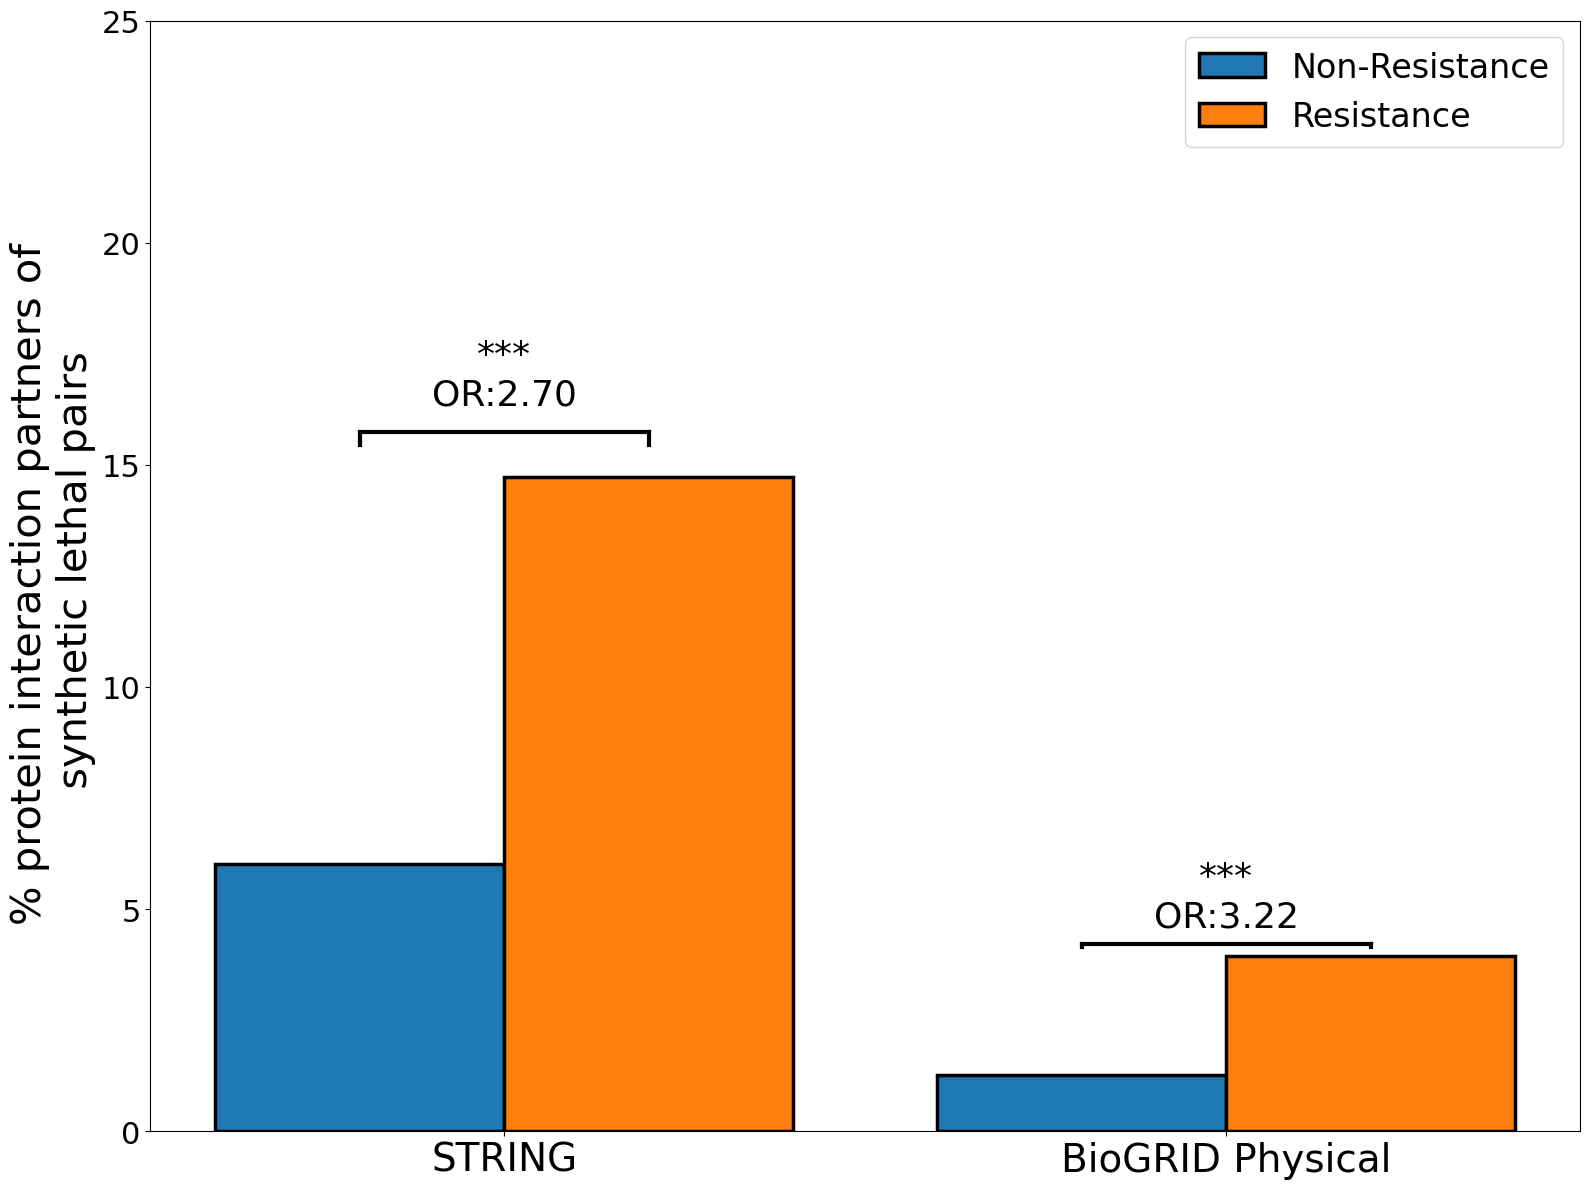

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

total_results = pd.read_csv('results/3_interaction_overlap_graphs/total_results_duplicate_allow.csv')

positions = range(len(total_results))
width = 0.4  

plt.figure(figsize=(16, 12))

# Plot the bars with bold edges
bars1 = plt.bar(
    [p - width/2 for p in positions], 
    total_results['Not_Resistant_ratio'], 
    width=width, 
    label='Non-Resistance', 
    edgecolor='black',
    linewidth=2.5
)
bars2 = plt.bar(
    [p + width/2 for p in positions], 
    total_results['Resistant_ratio'], 
    width=width, 
    label='Resistance', 
    edgecolor='black',
    linewidth=2.5
)

plt.ylim(0, 25)
plt.ylabel('% protein interaction partners of \n synthetic lethal pairs', fontsize=30)

# Set x-tick labels to "STRING" and "BIOGRID Physical"
plt.xticks(positions, ['STRING', 'BioGRID Physical'], fontsize=28)
plt.yticks(fontsize=22)

p_values = total_results['P_Value']
odds_ratios = total_results['Odds_Ratio']

# --- Significance stars function ---
def significance_stars(pval):
    if pval < 0.001:
        return "***"
    elif pval < 0.01:
        return "**"
    elif pval < 0.05:
        return "*"
    else:
        return "n.s."

def annotate_p_value(ax, bars1, bars2, p_values, odds_ratios):
    for idx, (bar1, bar2, p, or_val) in enumerate(zip(bars1, bars2, p_values, odds_ratios)):
        height = max(bar1.get_height(), bar2.get_height())
        line_height = height + 0.05 * height  
        bracket_height = 0.02 * height  

        # Use stars instead of raw p-value
        text = f'{significance_stars(p)}\nOR:{or_val:.2f}'
        
        # Draw bracket
        ax.plot([bar1.get_x() + bar1.get_width()/2, bar1.get_x() + bar1.get_width()/2], 
                [line_height, line_height + bracket_height], lw=3, color='black')
        ax.plot([bar2.get_x() + bar2.get_width()/2, bar2.get_x() + bar2.get_width()/2], 
                [line_height, line_height + bracket_height], lw=3, color='black')
        ax.plot([bar1.get_x() + bar1.get_width()/2, bar2.get_x() + bar2.get_width()/2], 
                [line_height + bracket_height, line_height + bracket_height], lw=3, color='black')
        
        # Add annotation text
        ax.annotate(text, 
                    xy=((bar1.get_x() + bar2.get_x() + bar1.get_width())/2, line_height + 2*bracket_height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=26)

annotate_p_value(plt.gca(), bars1, bars2, p_values, odds_ratios)

plt.legend(fontsize=24)
plt.tight_layout()
plt.savefig('results/3_interaction_overlap_graphs/figure2b_total_sum_table_asterisk_duplicate_allow.jpg', dpi=600)
plt.show()


# New Analysis of excluding specific groups for total analysis

## Tumor surpressor only ( BRCA, PTEN and ARID1A)

In [12]:
# Load all tsg_datasets into a dictionary
tsg_datasets = {
    "dunn_pten_pik3cb": pd.read_csv('results/2_interaction_overlap/string_results/dunn_PTEN_PIK3CB_string_results.csv'),
    "dunn_pten_akt": pd.read_csv('results/2_interaction_overlap/string_results/dunn_PTEN_AKT_string_results.csv'),
    "llorca_awwad_arid1a_atr": pd.read_csv('results/2_interaction_overlap/string_results/ARID1A_ATR_Awwad_Llorca_aggregated_string_results.csv'),
    "noordermeer_zimmermann_brca1_parp1": pd.read_csv('results/2_interaction_overlap/string_results/BRCA1_PARP1_Noordermeer_Zimmermann_aggregated_string_results.csv')
}

# Process each dataframe to add "Resistant" column
for name, df in tsg_datasets.items():
    # Add dataset name column
    df["Dataset"] = name

# Merge all DataFrames into a single DataFrame
merged_screen = pd.concat(tsg_datasets.values(), ignore_index=True)
merged_screen['Resistance'] = merged_screen['Resistance'].replace({"Not_Resistant": "NotResistant"})


resistant_rows = merged_screen[merged_screen["Resistance"] == "Resistant"]
#resistant_genes_rd = resistant_rows.drop_duplicates(subset=["Gene_corrected"], keep="first")
resistant_genes_rd = resistant_rows.reset_index()

not_resistant_rows = merged_screen[merged_screen["Resistance"] == "NotResistant"]
#not_resistant_genes_rd = not_resistant_rows.drop_duplicates(subset=["Gene_corrected"], keep="first")
not_resistant_genes_rd = not_resistant_rows.reset_index()

interacted_resistant = resistant_genes_rd[(resistant_genes_rd['Interaction_Partners'] == 'Partner') & (resistant_genes_rd['Resistance'] == 'Resistant')].shape[0]
interacted_no_resistant = not_resistant_genes_rd[(not_resistant_genes_rd['Interaction_Partners'] == 'Partner') & (not_resistant_genes_rd['Resistance'] == 'NotResistant')].shape[0]
no_interacted_resistant = resistant_genes_rd[(resistant_genes_rd['Interaction_Partners'] == 'Not partner') & (resistant_genes_rd['Resistance'] == 'Resistant')].shape[0]
no_interacted_no_resistant = not_resistant_genes_rd[(not_resistant_genes_rd['Interaction_Partners'] == 'Not partner') & (not_resistant_genes_rd['Resistance'] == 'NotResistant')].shape[0]

contingency_table = [[interacted_resistant, interacted_no_resistant],[no_interacted_resistant, no_interacted_no_resistant]]

odds_ratio, p_value = fisher_exact(contingency_table)

resistant_ratio = (interacted_resistant / (interacted_resistant+ no_interacted_resistant)) * 100
not_resistant_ratio = (interacted_no_resistant / (interacted_no_resistant+ no_interacted_no_resistant)) * 100


tsg_string_results = pd.DataFrame([{
    "Interacted_Resistant": interacted_resistant,
    "Interacted_No_Resistant": interacted_no_resistant,
    "No_Interacted_Resistant": no_interacted_resistant,
    "No_Interacted_No_Resistant": no_interacted_no_resistant,
    "Odds_Ratio": odds_ratio,
    "P_Value": p_value,
    "Resistant_ratio": resistant_ratio,
    "Not_Resistant_ratio" : not_resistant_ratio
}])

tsg_string_results

,Interacted_Resistant,Interacted_No_Resistant,No_Interacted_Resistant,No_Interacted_No_Resistant,Odds_Ratio,P_Value,Resistant_ratio,Not_Resistant_ratio
0,141,5024,626,66073,2.962233,8.164975e-25,18.383312,7.066402


In [13]:
# Load all tsg_datasets into a dictionary
tsg_datasets = {
    "dunn_pten_pik3cb": pd.read_csv('results/2_interaction_overlap/biogrid_results/dunn_PTEN_PIK3CB_biogrid_results.csv'),
    "dunn_pten_akt": pd.read_csv('results/2_interaction_overlap/biogrid_results/dunn_PTEN_AKT_biogrid_results.csv'),
    "llorca_awwad_arid1a_atr": pd.read_csv('results/2_interaction_overlap/biogrid_results/ARID1A_ATR_Awwad_Llorca_aggregated_biogrid_results.csv'),
    "noordermeer_zimmermann_brca1_parp1": pd.read_csv('results/2_interaction_overlap/biogrid_results/BRCA1_PARP1_Noordermeer_Zimmermann_aggregated_biogrid_results.csv')
}


# Process each dataframe to add "Resistant" column
for name, df in tsg_datasets.items():
    # Add dataset name column
    df["Dataset"] = name

# Merge all DataFrames into a single DataFrame
merged_screen = pd.concat(tsg_datasets.values(), ignore_index=True)
merged_screen['Resistance'] = merged_screen['Resistance'].replace({"Not_Resistant": "NotResistant"})


resistant_rows = merged_screen[merged_screen["Resistance"] == "Resistant"]
#resistant_genes_rd = resistant_rows.drop_duplicates(subset=["Gene_corrected"], keep="first")
resistant_genes_rd = resistant_rows.reset_index()

not_resistant_rows = merged_screen[merged_screen["Resistance"] == "NotResistant"]
#not_resistant_genes_rd = not_resistant_rows.drop_duplicates(subset=["Gene_corrected"], keep="first")
not_resistant_genes_rd = not_resistant_rows.reset_index()

interacted_resistant = resistant_genes_rd[(resistant_genes_rd['Interaction_Partners'] == 'Partner') & (resistant_genes_rd['Resistance'] == 'Resistant')].shape[0]
interacted_no_resistant = not_resistant_genes_rd[(not_resistant_genes_rd['Interaction_Partners'] == 'Partner') & (not_resistant_genes_rd['Resistance'] == 'NotResistant')].shape[0]
no_interacted_resistant = resistant_genes_rd[(resistant_genes_rd['Interaction_Partners'] == 'Not partner') & (resistant_genes_rd['Resistance'] == 'Resistant')].shape[0]
no_interacted_no_resistant = not_resistant_genes_rd[(not_resistant_genes_rd['Interaction_Partners'] == 'Not partner') & (not_resistant_genes_rd['Resistance'] == 'NotResistant')].shape[0]

contingency_table = [[interacted_resistant, interacted_no_resistant],[no_interacted_resistant, no_interacted_no_resistant]]

odds_ratio, p_value = fisher_exact(contingency_table)

resistant_ratio = (interacted_resistant / (interacted_resistant+ no_interacted_resistant)) * 100
not_resistant_ratio = (interacted_no_resistant / (interacted_no_resistant+ no_interacted_no_resistant)) * 100


tsg_biogrid_results = pd.DataFrame([{
    "Interacted_Resistant": interacted_resistant,
    "Interacted_No_Resistant": interacted_no_resistant,
    "No_Interacted_Resistant": no_interacted_resistant,
    "No_Interacted_No_Resistant": no_interacted_no_resistant,
    "Odds_Ratio": odds_ratio,
    "P_Value": p_value,
    "Resistant_ratio": resistant_ratio,
    "Not_Resistant_ratio" : not_resistant_ratio
}])

tsg_biogrid_results

,Interacted_Resistant,Interacted_No_Resistant,No_Interacted_Resistant,No_Interacted_No_Resistant,Odds_Ratio,P_Value,Resistant_ratio,Not_Resistant_ratio
0,48,952,719,70145,4.918947,1.066954e-17,6.258149,1.339016


In [14]:
tsg_total_results = pd.concat([tsg_string_results,tsg_biogrid_results],axis=0)
tsg_total_results= tsg_total_results.reset_index(inplace=False,drop=True)
tsg_total_results

,Interacted_Resistant,Interacted_No_Resistant,No_Interacted_Resistant,No_Interacted_No_Resistant,Odds_Ratio,P_Value,Resistant_ratio,Not_Resistant_ratio
0,141,5024,626,66073,2.962233,8.164975e-25,18.383312,7.066402
1,48,952,719,70145,4.918947,1.066954e-17,6.258149,1.339016


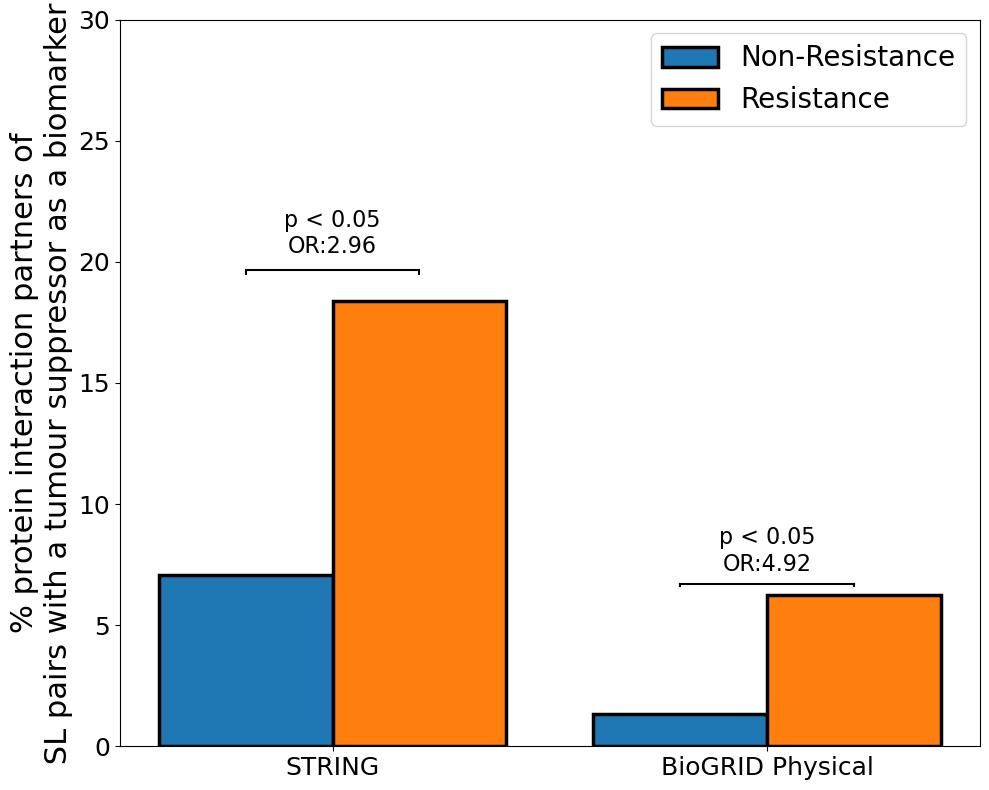

In [15]:
import matplotlib.pyplot as plt

# Assuming 'tsg_total_results' is a DataFrame with necessary data
positions = range(len(tsg_total_results))
width = 0.4  # Making the bar a bit thinner

plt.figure(figsize=(10, 8))

# Plot the bars with bold edges
bars1 = plt.bar(
    [p - width/2 for p in positions], 
    tsg_total_results['Not_Resistant_ratio'], 
    width=width, 
    label='Non-Resistance', 
    edgecolor='black',  # Black border for the bars
    linewidth=2.5  # Thickness of the bar boundary
)
bars2 = plt.bar(
    [p + width/2 for p in positions], 
    tsg_total_results['Resistant_ratio'], 
    width=width, 
    label='Resistance', 
    edgecolor='black',  # Black border for the bars
    linewidth=2.5  # Thickness of the bar boundary
)

plt.ylim(0, 30)
plt.ylabel('% protein interaction partners of\n SL pairs with a tumour suppressor as a biomarker ', fontsize=22)

# Set x-tick labels to "STRING" and "BIOGRID Physical"
plt.xticks(positions, ['STRING', 'BioGRID Physical'], fontsize=18)
plt.yticks(fontsize=18)

p_values = tsg_total_results['P_Value']
odds_ratios = tsg_total_results['Odds_Ratio']  # Assuming this exists

def annotate_p_value(ax, bars1, bars2, p_values, odds_ratios):
    for idx, (bar1, bar2, p, or_val) in enumerate(zip(bars1, bars2, p_values, odds_ratios)):
        height = max(bar1.get_height(), bar2.get_height()) + 0.05 * max(bar1.get_height(), bar2.get_height())
        line_height = height + 0.01 * max(bar1.get_height(), bar2.get_height())  # Adjusting line height
        
        # Adjusted to display OR value
        if p < 0.05:
            text = f'p < 0.05\nOR:{or_val:.2f}'  # Show OR value with 2 decimal places
        else:
            text = f'n.s.\nOR:{or_val:.2f}'
        
        bracket_height = 0.01 * max(bar1.get_height(), bar2.get_height())
        ax.plot([bar1.get_x() + bar1.get_width()/2, bar1.get_x() + bar1.get_width()/2], [line_height, line_height + bracket_height], lw=1.5, color='black')
        ax.plot([bar2.get_x() + bar2.get_width()/2, bar2.get_x() + bar2.get_width()/2], [line_height, line_height + bracket_height], lw=1.5, color='black')
        ax.plot([bar1.get_x() + bar1.get_width()/2, bar2.get_x() + bar2.get_width()/2], [line_height + bracket_height, line_height + bracket_height], lw=1.5, color='black')
        
        ax.annotate(text, xy=((bar1.get_x() + bar2.get_x() + bar1.get_width())/2, line_height + 2*bracket_height),
                    xytext=(0, 5),  # Adjust vertical offset to accommodate OR
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=16)  # Adjust font size if necessary

annotate_p_value(plt.gca(), bars1, bars2, p_values, odds_ratios)

plt.legend(fontsize=20)
plt.tight_layout()
plt.savefig('results/3_interaction_overlap_graphs/supplementary_fig_2_tsg_total.jpeg',dpi=600)
plt.show()


## Excluding the PARP inhibitor

In [16]:
import pandas as pd
# Load all datasets into a dictionary
exc_brca_datasets  = {
    "dunn_pten_pik3cb": pd.read_csv('results/2_interaction_overlap/string_results/dunn_PTEN_PIK3CB_string_results.csv'),
    "dunn_pten_akt": pd.read_csv('results/2_interaction_overlap/string_results/dunn_PTEN_AKT_string_results.csv'),
    "llorca_awwad_arid1a_atr": pd.read_csv('results/2_interaction_overlap/string_results/ARID1A_ATR_Awwad_Llorca_aggregated_string_results.csv'),
    "krall_wang_yu_kras_mek": pd.read_csv('results/2_interaction_overlap/string_results/KRAS_MEK_Krall_Wang_Yu_aggregated_string_results.csv'),
    "hayes_krall_nras_mek": pd.read_csv('results/2_interaction_overlap/string_results/NRAS_MEK_Hayes_Krall_aggregated_string_results.csv'),
    "hayes_nras_cdk46": pd.read_csv('results/2_interaction_overlap/string_results/hayes_NRAS_CDK4_6_string_results.csv'),
    "krall_braf_mek": pd.read_csv('results/2_interaction_overlap/string_results/krall_BRAF_MEK_string_results.csv')}

# Process each dataframe to add "Resistant" column
for name, df in exc_brca_datasets.items():
    # Add dataset name column
    df["Dataset"] = name

# Merge all DataFrames into a single DataFrame
merged_screen = pd.concat(exc_brca_datasets.values(), ignore_index=True)
merged_screen['Resistance'] = merged_screen['Resistance'].replace({"Not_Resistant": "NotResistant"})


resistant_rows = merged_screen[merged_screen["Resistance"] == "Resistant"]
#resistant_genes_rd = resistant_rows.drop_duplicates(subset=["Gene_corrected"], keep="first")
resistant_genes_rd = resistant_rows.reset_index()

not_resistant_rows = merged_screen[merged_screen["Resistance"] == "NotResistant"]
#not_resistant_genes_rd = not_resistant_rows.drop_duplicates(subset=["Gene_corrected"], keep="first")
not_resistant_genes_rd = not_resistant_rows.reset_index()

interacted_resistant = resistant_genes_rd[(resistant_genes_rd['Interaction_Partners'] == 'Partner') & (resistant_genes_rd['Resistance'] == 'Resistant')].shape[0]
interacted_no_resistant = not_resistant_genes_rd[(not_resistant_genes_rd['Interaction_Partners'] == 'Partner') & (not_resistant_genes_rd['Resistance'] == 'NotResistant')].shape[0]
no_interacted_resistant = resistant_genes_rd[(resistant_genes_rd['Interaction_Partners'] == 'Not partner') & (resistant_genes_rd['Resistance'] == 'Resistant')].shape[0]
no_interacted_no_resistant = not_resistant_genes_rd[(not_resistant_genes_rd['Interaction_Partners'] == 'Not partner') & (not_resistant_genes_rd['Resistance'] == 'NotResistant')].shape[0]

contingency_table = [[interacted_resistant, interacted_no_resistant],[no_interacted_resistant, no_interacted_no_resistant]]

odds_ratio, p_value = fisher_exact(contingency_table)

resistant_ratio = (interacted_resistant / (interacted_resistant+ no_interacted_resistant)) * 100
not_resistant_ratio = (interacted_no_resistant / (interacted_no_resistant+ no_interacted_no_resistant)) * 100


exc_brca_string_results = pd.DataFrame([{
    "Interacted_Resistant": interacted_resistant,
    "Interacted_No_Resistant": interacted_no_resistant,
    "No_Interacted_Resistant": no_interacted_resistant,
    "No_Interacted_No_Resistant": no_interacted_no_resistant,
    "Odds_Ratio": odds_ratio,
    "P_Value": p_value,
    "Resistant_ratio": resistant_ratio,
    "Not_Resistant_ratio" : not_resistant_ratio
}])

exc_brca_string_results

,Interacted_Resistant,Interacted_No_Resistant,No_Interacted_Resistant,No_Interacted_No_Resistant,Odds_Ratio,P_Value,Resistant_ratio,Not_Resistant_ratio
0,196,7388,1124,118369,2.793836,1.381915e-31,14.848485,5.874822


In [17]:
import pandas as pd
# Load all datasets into a dictionary
exc_brca_datasets  = {
    "dunn_pten_pik3cb": pd.read_csv('results/2_interaction_overlap/biogrid_results/dunn_PTEN_PIK3CB_biogrid_results.csv'),
    "dunn_pten_akt": pd.read_csv('results/2_interaction_overlap/biogrid_results/dunn_PTEN_AKT_biogrid_results.csv'),
    "llorca_awwad_arid1a_atr": pd.read_csv('results/2_interaction_overlap/biogrid_results/ARID1A_ATR_Awwad_Llorca_aggregated_biogrid_results.csv'),
    "krall_wang_yu_kras_mek": pd.read_csv('results/2_interaction_overlap/biogrid_results/KRAS_MEK_Krall_Wang_Yu_aggregated_biogrid_results.csv'),
    "hayes_krall_nras_mek": pd.read_csv('results/2_interaction_overlap/biogrid_results/NRAS_MEK_Hayes_Krall_aggregated_biogrid_results.csv'),
    "hayes_nras_cdk46": pd.read_csv('results/2_interaction_overlap/biogrid_results/hayes_NRAS_CDK4_6_biogrid_results.csv'),
    "krall_braf_mek": pd.read_csv('results/2_interaction_overlap/biogrid_results/krall_BRAF_MEK_biogrid_results.csv')}

# Process each dataframe to add "Resistant" column
for name, df in exc_brca_datasets.items():
    # Add dataset name column
    df["Dataset"] = name

# Merge all DataFrames into a single DataFrame
merged_screen = pd.concat(exc_brca_datasets.values(), ignore_index=True)
merged_screen['Resistance'] = merged_screen['Resistance'].replace({"Not_Resistant": "NotResistant"})


resistant_rows = merged_screen[merged_screen["Resistance"] == "Resistant"]
#resistant_genes_rd = resistant_rows.drop_duplicates(subset=["Gene_corrected"], keep="first")
resistant_genes_rd = resistant_rows.reset_index()

not_resistant_rows = merged_screen[merged_screen["Resistance"] == "NotResistant"]
#not_resistant_genes_rd = not_resistant_rows.drop_duplicates(subset=["Gene_corrected"], keep="first")
not_resistant_genes_rd =not_resistant_rows.reset_index()

interacted_resistant = resistant_genes_rd[(resistant_genes_rd['Interaction_Partners'] == 'Partner') & (resistant_genes_rd['Resistance'] == 'Resistant')].shape[0]
interacted_no_resistant = not_resistant_genes_rd[(not_resistant_genes_rd['Interaction_Partners'] == 'Partner') & (not_resistant_genes_rd['Resistance'] == 'NotResistant')].shape[0]
no_interacted_resistant = resistant_genes_rd[(resistant_genes_rd['Interaction_Partners'] == 'Not partner') & (resistant_genes_rd['Resistance'] == 'Resistant')].shape[0]
no_interacted_no_resistant = not_resistant_genes_rd[(not_resistant_genes_rd['Interaction_Partners'] == 'Not partner') & (not_resistant_genes_rd['Resistance'] == 'NotResistant')].shape[0]

contingency_table = [[interacted_resistant, interacted_no_resistant],[no_interacted_resistant, no_interacted_no_resistant]]

odds_ratio, p_value = fisher_exact(contingency_table)

resistant_ratio = (interacted_resistant / (interacted_resistant+ no_interacted_resistant)) * 100
not_resistant_ratio = (interacted_no_resistant / (interacted_no_resistant+ no_interacted_no_resistant)) * 100


exc_brca_biogrid_results = pd.DataFrame([{
    "Interacted_Resistant": interacted_resistant,
    "Interacted_No_Resistant": interacted_no_resistant,
    "No_Interacted_Resistant": no_interacted_resistant,
    "No_Interacted_No_Resistant": no_interacted_no_resistant,
    "Odds_Ratio": odds_ratio,
    "P_Value": p_value,
    "Resistant_ratio": resistant_ratio,
    "Not_Resistant_ratio" : not_resistant_ratio
}])

exc_brca_biogrid_results

,Interacted_Resistant,Interacted_No_Resistant,No_Interacted_Resistant,No_Interacted_No_Resistant,Odds_Ratio,P_Value,Resistant_ratio,Not_Resistant_ratio
0,43,1344,1277,124413,3.117052,4.870538e-10,3.257576,1.068728


In [18]:
exc_brca_total_results = pd.concat([exc_brca_string_results,exc_brca_biogrid_results],axis=0)
exc_brca_total_results= exc_brca_total_results.reset_index(inplace=False,drop=True)
exc_brca_total_results

,Interacted_Resistant,Interacted_No_Resistant,No_Interacted_Resistant,No_Interacted_No_Resistant,Odds_Ratio,P_Value,Resistant_ratio,Not_Resistant_ratio
0,196,7388,1124,118369,2.793836,1.381915e-31,14.848485,5.874822
1,43,1344,1277,124413,3.117052,4.870538e-10,3.257576,1.068728


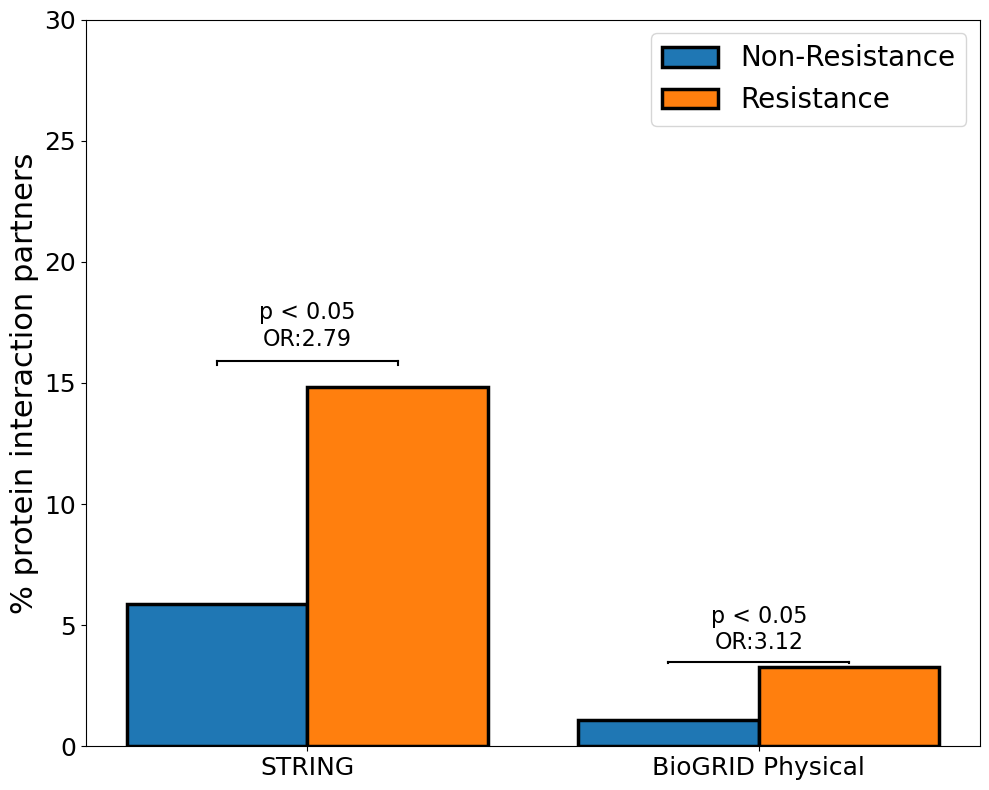

In [19]:
import matplotlib.pyplot as plt

# Assuming 'exc_brca_total_results' is a DataFrame with necessary data
positions = range(len(exc_brca_total_results))
width = 0.4  # Making the bar a bit thinner

plt.figure(figsize=(10, 8))

# Plot the bars with bold edges
bars1 = plt.bar(
    [p - width/2 for p in positions], 
    exc_brca_total_results['Not_Resistant_ratio'], 
    width=width, 
    label='Non-Resistance', 
    edgecolor='black',  # Black border for the bars
    linewidth=2.5  # Thickness of the bar boundary
)
bars2 = plt.bar(
    [p + width/2 for p in positions], 
    exc_brca_total_results['Resistant_ratio'], 
    width=width, 
    label='Resistance', 
    edgecolor='black',  # Black border for the bars
    linewidth=2.5  # Thickness of the bar boundary
)

plt.ylim(0, 30)
plt.ylabel('% protein interaction partners', fontsize=22)

# Set x-tick labels to "STRING" and "BIOGRID Physical"
plt.xticks(positions, ['STRING', 'BioGRID Physical'], fontsize=18)
plt.yticks(fontsize=18)

p_values = exc_brca_total_results['P_Value']
odds_ratios = exc_brca_total_results['Odds_Ratio']  # Assuming this exists

def annotate_p_value(ax, bars1, bars2, p_values, odds_ratios):
    for idx, (bar1, bar2, p, or_val) in enumerate(zip(bars1, bars2, p_values, odds_ratios)):
        height = max(bar1.get_height(), bar2.get_height()) + 0.05 * max(bar1.get_height(), bar2.get_height())
        line_height = height + 0.01 * max(bar1.get_height(), bar2.get_height())  # Adjusting line height
        
        # Adjusted to display OR value
        if p < 0.05:
            text = f'p < 0.05\nOR:{or_val:.2f}'  # Show OR value with 2 decimal places
        else:
            text = f'n.s.\nOR:{or_val:.2f}'
        
        bracket_height = 0.01 * max(bar1.get_height(), bar2.get_height())
        ax.plot([bar1.get_x() + bar1.get_width()/2, bar1.get_x() + bar1.get_width()/2], [line_height, line_height + bracket_height], lw=1.5, color='black')
        ax.plot([bar2.get_x() + bar2.get_width()/2, bar2.get_x() + bar2.get_width()/2], [line_height, line_height + bracket_height], lw=1.5, color='black')
        ax.plot([bar1.get_x() + bar1.get_width()/2, bar2.get_x() + bar2.get_width()/2], [line_height + bracket_height, line_height + bracket_height], lw=1.5, color='black')
        
        ax.annotate(text, xy=((bar1.get_x() + bar2.get_x() + bar1.get_width())/2, line_height + 2*bracket_height),
                    xytext=(0, 5),  # Adjust vertical offset to accommodate OR
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=16)  # Adjust font size if necessary

annotate_p_value(plt.gca(), bars1, bars2, p_values, odds_ratios)

plt.legend(fontsize=20)
plt.tight_layout()
plt.savefig('results/3_interaction_overlap_graphs/supplementary_fig_2_brca_exc_total.jpeg',dpi=600)
plt.show()


## Excluding Mek only

In [20]:
exc_mek_datasets = {
    "dunn_pten_pik3cb": pd.read_csv('results/2_interaction_overlap/string_results/dunn_PTEN_PIK3CB_string_results.csv'),
    "dunn_pten_akt": pd.read_csv('results/2_interaction_overlap/string_results/dunn_PTEN_AKT_string_results.csv'),
    "llorca_awwad_arid1a_atr": pd.read_csv('results/2_interaction_overlap/string_results/ARID1A_ATR_Awwad_Llorca_aggregated_string_results.csv'),
    "noordermeer_zimmermann_brca1_parp1": pd.read_csv('results/2_interaction_overlap/string_results/BRCA1_PARP1_Noordermeer_Zimmermann_aggregated_string_results.csv'),
    "hayes_nras_cdk46": pd.read_csv('results/2_interaction_overlap/string_results/hayes_NRAS_CDK4_6_string_results.csv'),
    "krall_braf_mek": pd.read_csv('results/2_interaction_overlap/string_results/krall_BRAF_MEK_string_results.csv')}

# Process each dataframe to add "Resistant" column
for name, df in exc_mek_datasets .items():
    # Add dataset name column
    df["Dataset"] = name

# Merge all DataFrames into a single DataFrame
merged_screen = pd.concat(exc_mek_datasets.values(), ignore_index=True)
merged_screen['Resistance'] = merged_screen['Resistance'].replace({"Not_Resistant": "NotResistant"})


resistant_rows = merged_screen[merged_screen["Resistance"] == "Resistant"]
#resistant_genes_rd = resistant_rows.drop_duplicates(subset=["Gene_corrected"], keep="first")
resistant_genes_rd = resistant_rows.reset_index()

not_resistant_rows = merged_screen[merged_screen["Resistance"] == "NotResistant"]
#not_resistant_genes_rd = not_resistant_rows.drop_duplicates(subset=["Gene_corrected"], keep="first")
not_resistant_genes_rd = not_resistant_rows.reset_index()

interacted_resistant = resistant_genes_rd[(resistant_genes_rd['Interaction_Partners'] == 'Partner') & (resistant_genes_rd['Resistance'] == 'Resistant')].shape[0]
interacted_no_resistant = not_resistant_genes_rd[(not_resistant_genes_rd['Interaction_Partners'] == 'Partner') & (not_resistant_genes_rd['Resistance'] == 'NotResistant')].shape[0]
no_interacted_resistant = resistant_genes_rd[(resistant_genes_rd['Interaction_Partners'] == 'Not partner') & (resistant_genes_rd['Resistance'] == 'Resistant')].shape[0]
no_interacted_no_resistant = not_resistant_genes_rd[(not_resistant_genes_rd['Interaction_Partners'] == 'Not partner') & (not_resistant_genes_rd['Resistance'] == 'NotResistant')].shape[0]

contingency_table = [[interacted_resistant, interacted_no_resistant],[no_interacted_resistant, no_interacted_no_resistant]]

odds_ratio, p_value = fisher_exact(contingency_table)

resistant_ratio = (interacted_resistant / (interacted_resistant+ no_interacted_resistant)) * 100
not_resistant_ratio = (interacted_no_resistant / (interacted_no_resistant+ no_interacted_no_resistant)) * 100


exc_mek_string_results = pd.DataFrame([{
    "Interacted_Resistant": interacted_resistant,
    "Interacted_No_Resistant": interacted_no_resistant,
    "No_Interacted_Resistant": no_interacted_resistant,
    "No_Interacted_No_Resistant": no_interacted_no_resistant,
    "Odds_Ratio": odds_ratio,
    "P_Value": p_value,
    "Resistant_ratio": resistant_ratio,
    "Not_Resistant_ratio" : not_resistant_ratio
}])

exc_mek_string_results

,Interacted_Resistant,Interacted_No_Resistant,No_Interacted_Resistant,No_Interacted_No_Resistant,Odds_Ratio,P_Value,Resistant_ratio,Not_Resistant_ratio
0,168,6779,766,99197,3.209323,4.313153e-33,17.987152,6.396731


In [21]:
exc_mek_datasets = {
    "dunn_pten_pik3cb": pd.read_csv('results/2_interaction_overlap/biogrid_results/dunn_PTEN_PIK3CB_biogrid_results.csv'),
    "dunn_pten_akt": pd.read_csv('results/2_interaction_overlap/biogrid_results/dunn_PTEN_AKT_biogrid_results.csv'),
    "llorca_awwad_arid1a_atr": pd.read_csv('results/2_interaction_overlap/biogrid_results/ARID1A_ATR_Awwad_Llorca_aggregated_biogrid_results.csv'),
    "noordermeer_zimmermann_brca1_parp1": pd.read_csv('results/2_interaction_overlap/biogrid_results/BRCA1_PARP1_Noordermeer_Zimmermann_aggregated_biogrid_results.csv'),
    "hayes_nras_cdk46": pd.read_csv('results/2_interaction_overlap/biogrid_results/hayes_NRAS_CDK4_6_biogrid_results.csv'),
    "krall_braf_mek": pd.read_csv('results/2_interaction_overlap/biogrid_results/krall_BRAF_MEK_biogrid_results.csv')}

# Process each dataframe to add "Resistant" column
for name, df in exc_mek_datasets .items():
    # Add dataset name column
    df["Dataset"] = name

# Merge all DataFrames into a single DataFrame
merged_screen = pd.concat(exc_mek_datasets.values(), ignore_index=True)
merged_screen['Resistance'] = merged_screen['Resistance'].replace({"Not_Resistant": "NotResistant"})


resistant_rows = merged_screen[merged_screen["Resistance"] == "Resistant"]
#resistant_genes_rd = resistant_rows.drop_duplicates(subset=["Gene_corrected"], keep="first")
resistant_genes_rd = resistant_rows.reset_index()

not_resistant_rows = merged_screen[merged_screen["Resistance"] == "NotResistant"]
#not_resistant_genes_rd = not_resistant_rows.drop_duplicates(subset=["Gene_corrected"], keep="first")
not_resistant_genes_rd = not_resistant_rows.reset_index()

interacted_resistant = resistant_genes_rd[(resistant_genes_rd['Interaction_Partners'] == 'Partner') & (resistant_genes_rd['Resistance'] == 'Resistant')].shape[0]
interacted_no_resistant = not_resistant_genes_rd[(not_resistant_genes_rd['Interaction_Partners'] == 'Partner') & (not_resistant_genes_rd['Resistance'] == 'NotResistant')].shape[0]
no_interacted_resistant = resistant_genes_rd[(resistant_genes_rd['Interaction_Partners'] == 'Not partner') & (resistant_genes_rd['Resistance'] == 'Resistant')].shape[0]
no_interacted_no_resistant = not_resistant_genes_rd[(not_resistant_genes_rd['Interaction_Partners'] == 'Not partner') & (not_resistant_genes_rd['Resistance'] == 'NotResistant')].shape[0]

contingency_table = [[interacted_resistant, interacted_no_resistant],[no_interacted_resistant, no_interacted_no_resistant]]

odds_ratio, p_value = fisher_exact(contingency_table)

resistant_ratio = (interacted_resistant / (interacted_resistant+ no_interacted_resistant)) * 100
not_resistant_ratio = (interacted_no_resistant / (interacted_no_resistant+ no_interacted_no_resistant)) * 100


exc_mek_biogrid_results = pd.DataFrame([{
    "Interacted_Resistant": interacted_resistant,
    "Interacted_No_Resistant": interacted_no_resistant,
    "No_Interacted_Resistant": no_interacted_resistant,
    "No_Interacted_No_Resistant": no_interacted_no_resistant,
    "Odds_Ratio": odds_ratio,
    "P_Value": p_value,
    "Resistant_ratio": resistant_ratio,
    "Not_Resistant_ratio" : not_resistant_ratio
}])

exc_mek_biogrid_results

,Interacted_Resistant,Interacted_No_Resistant,No_Interacted_Resistant,No_Interacted_No_Resistant,Odds_Ratio,P_Value,Resistant_ratio,Not_Resistant_ratio
0,52,1194,882,104782,5.173889,4.859587e-20,5.567452,1.12667


In [22]:
exc_mek_total_results = pd.concat([exc_mek_string_results,exc_mek_biogrid_results],axis=0)
exc_mek_total_results= exc_mek_total_results.reset_index(inplace=False,drop=True)
exc_mek_total_results

,Interacted_Resistant,Interacted_No_Resistant,No_Interacted_Resistant,No_Interacted_No_Resistant,Odds_Ratio,P_Value,Resistant_ratio,Not_Resistant_ratio
0,168,6779,766,99197,3.209323,4.313153e-33,17.987152,6.396731
1,52,1194,882,104782,5.173889,4.859587e-20,5.567452,1.126670


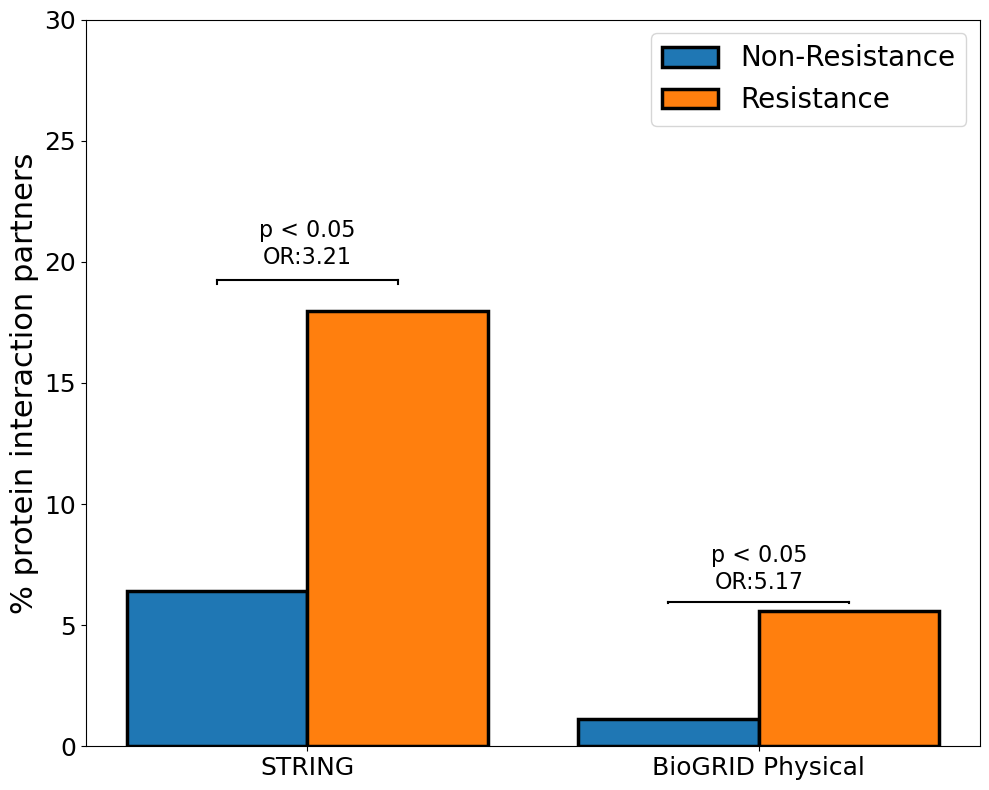

In [23]:
import matplotlib.pyplot as plt

# Assuming 'exc_mek_total_results' is a DataFrame with necessary data
positions = range(len(exc_mek_total_results))
width = 0.4  # Making the bar a bit thinner

plt.figure(figsize=(10, 8))

# Plot the bars with bold edges
bars1 = plt.bar(
    [p - width/2 for p in positions], 
    exc_mek_total_results['Not_Resistant_ratio'], 
    width=width, 
    label='Non-Resistance', 
    edgecolor='black',  # Black border for the bars
    linewidth=2.5  # Thickness of the bar boundary
)
bars2 = plt.bar(
    [p + width/2 for p in positions], 
    exc_mek_total_results['Resistant_ratio'], 
    width=width, 
    label='Resistance', 
    edgecolor='black',  # Black border for the bars
    linewidth=2.5  # Thickness of the bar boundary
)

plt.ylim(0, 30)
plt.ylabel('% protein interaction partners', fontsize=22)

# Set x-tick labels to "STRING" and "BIOGRID Physical"
plt.xticks(positions, ['STRING', 'BioGRID Physical'], fontsize=18)
plt.yticks(fontsize=18)

p_values = exc_mek_total_results['P_Value']
odds_ratios = exc_mek_total_results['Odds_Ratio']  # Assuming this exists

def annotate_p_value(ax, bars1, bars2, p_values, odds_ratios):
    for idx, (bar1, bar2, p, or_val) in enumerate(zip(bars1, bars2, p_values, odds_ratios)):
        height = max(bar1.get_height(), bar2.get_height()) + 0.05 * max(bar1.get_height(), bar2.get_height())
        line_height = height + 0.01 * max(bar1.get_height(), bar2.get_height())  # Adjusting line height
        
        # Adjusted to display OR value
        if p < 0.05:
            text = f'p < 0.05\nOR:{or_val:.2f}'  # Show OR value with 2 decimal places
        else:
            text = f'n.s.\nOR:{or_val:.2f}'
        
        bracket_height = 0.01 * max(bar1.get_height(), bar2.get_height())
        ax.plot([bar1.get_x() + bar1.get_width()/2, bar1.get_x() + bar1.get_width()/2], [line_height, line_height + bracket_height], lw=1.5, color='black')
        ax.plot([bar2.get_x() + bar2.get_width()/2, bar2.get_x() + bar2.get_width()/2], [line_height, line_height + bracket_height], lw=1.5, color='black')
        ax.plot([bar1.get_x() + bar1.get_width()/2, bar2.get_x() + bar2.get_width()/2], [line_height + bracket_height, line_height + bracket_height], lw=1.5, color='black')
        
        ax.annotate(text, xy=((bar1.get_x() + bar2.get_x() + bar1.get_width())/2, line_height + 2*bracket_height),
                    xytext=(0, 5),  # Adjust vertical offset to accommodate OR
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=16)  # Adjust font size if necessary

annotate_p_value(plt.gca(), bars1, bars2, p_values, odds_ratios)

plt.legend(fontsize=20)
plt.tight_layout()
plt.savefig('results/3_interaction_overlap_graphs/supplementary_fig_2_exc_mek.jpeg',dpi=600)
plt.show()


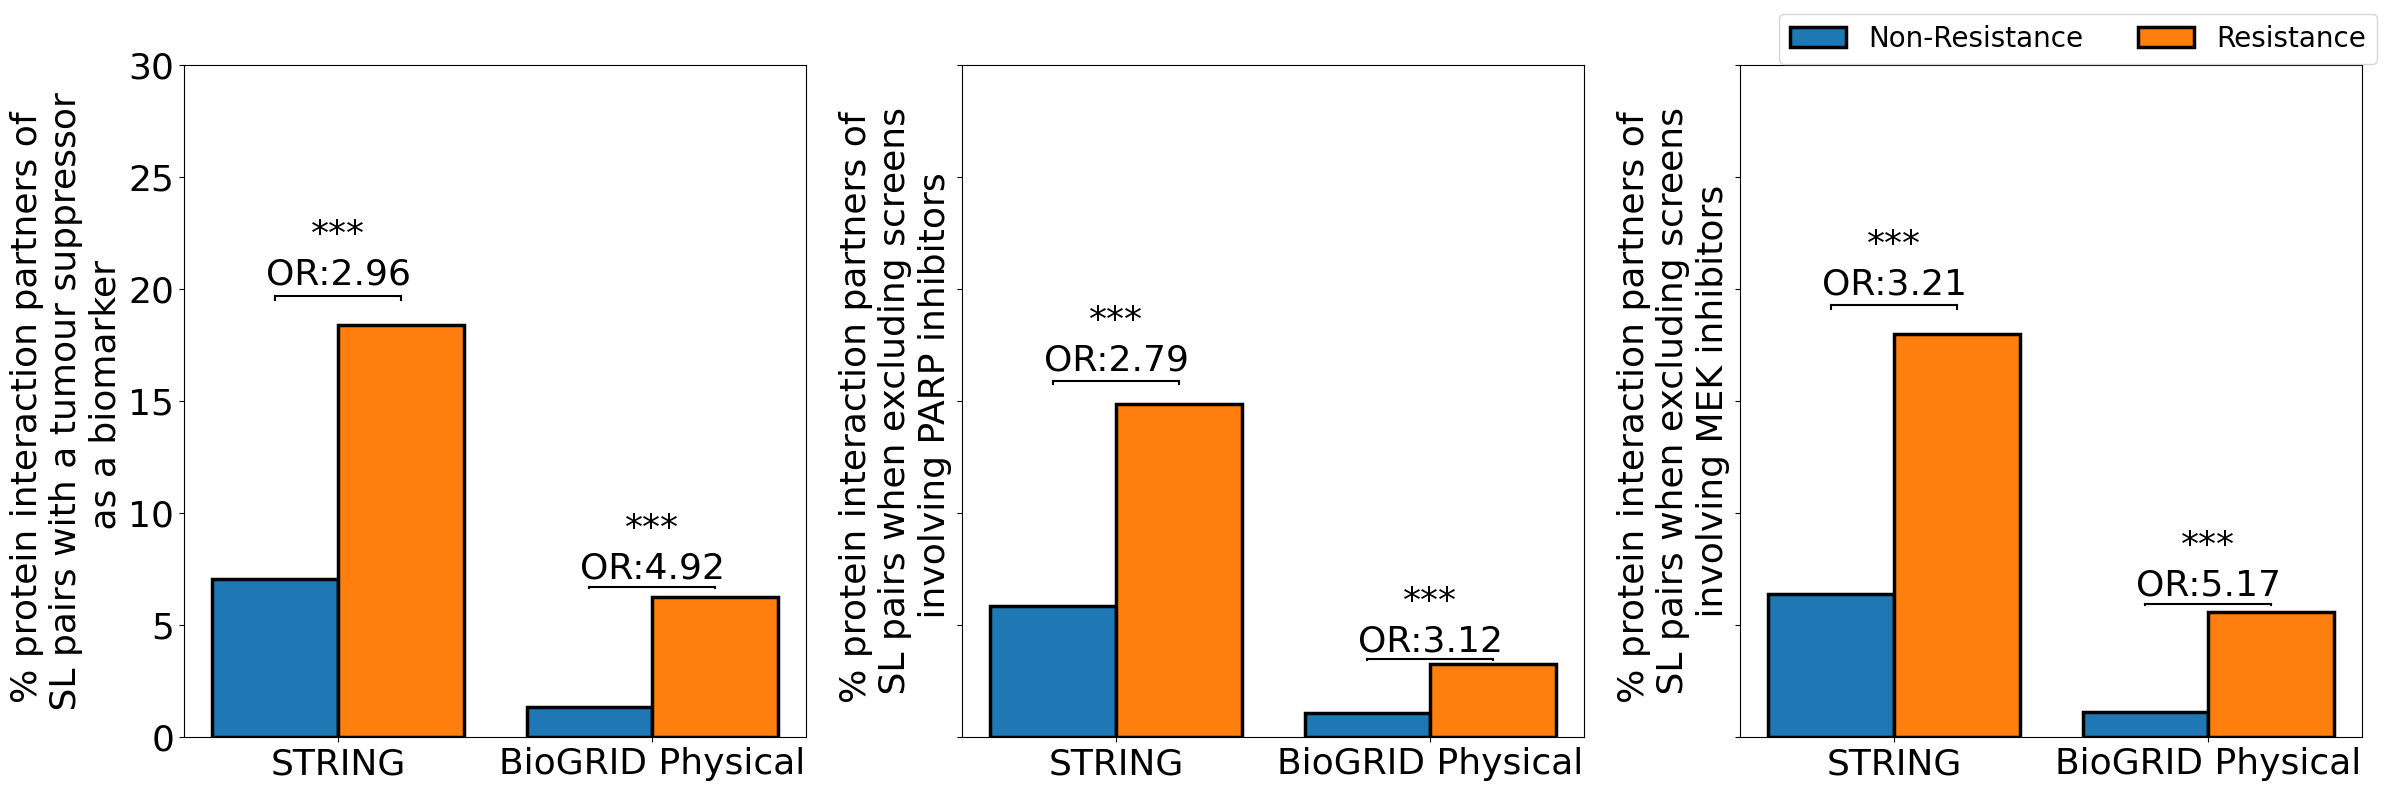

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True)

# List your datasets and titles for easy looping
data_list = [
    (tsg_total_results, '% protein interaction partners of \n SL pairs with a tumour suppressor \n as a biomarker'),
    (exc_brca_total_results, '% protein interaction partners of \n SL pairs when excluding screens \n involving PARP inhibitors'),
    (exc_mek_total_results, '% protein interaction partners of \n SL pairs when excluding screens \n involving MEK inhibitors ')
]

width = 0.4

# --- significance stars function ---
def significance_stars(pval):
    if pval < 0.001:
        return "***"
    elif pval < 0.01:
        return "**"
    elif pval < 0.05:
        return "*"
    else:
        return ""   # nothing if not significant

for ax, (data, ylabel) in zip(axes, data_list):
    positions = range(len(data))

    bars1 = ax.bar(
        [p - width/2 for p in positions], 
        data['Not_Resistant_ratio'], 
        width=width, 
        label='Non-Resistance', 
        edgecolor='black', linewidth=2.5
    )
    bars2 = ax.bar(
        [p + width/2 for p in positions], 
        data['Resistant_ratio'], 
        width=width, 
        label='Resistance', 
        edgecolor='black', linewidth=2.5
    )

    ax.set_ylim(0, 30)
    ax.set_ylabel(ylabel, fontsize=26)
    ax.set_xticks(positions)
    ax.set_xticklabels(['STRING', 'BioGRID Physical'], fontsize=26)
    ax.tick_params(axis='y', labelsize=26)

    # Annotation for asterisks + OR
    p_values = data['P_Value']
    odds_ratios = data['Odds_Ratio']

    def annotate_p_value(ax, bars1, bars2, p_values, odds_ratios):
        for bar1, bar2, p, or_val in zip(bars1, bars2, p_values, odds_ratios):
            height = max(bar1.get_height(), bar2.get_height()) * 1.05
            line_height = height * 1.01

            stars = significance_stars(p)
            if stars:
                text = f"{stars}\nOR:{or_val:.2f}"
            else:
                text = f"OR:{or_val:.2f}"

            bracket_height = height * 0.01
            ax.plot([bar1.get_x() + width/2, bar1.get_x() + width/2],
                    [line_height, line_height + bracket_height], lw=1.5, color='black')
            ax.plot([bar2.get_x() + width/2, bar2.get_x() + width/2],
                    [line_height, line_height + bracket_height], lw=1.5, color='black')
            ax.plot([bar1.get_x() + width/2, bar2.get_x() + width/2],
                    [line_height + bracket_height, line_height + bracket_height], lw=1.5, color='black')

            ax.annotate(text,
                        xy=((bar1.get_x() + bar2.get_x() + width)/2, line_height + 2*bracket_height),
                        xytext=(0, 5), textcoords="offset points",
                        ha='center', fontsize=26)

    annotate_p_value(ax, bars1, bars2, p_values, odds_ratios)

# Single shared legend for clarity
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=20, ncol=2)

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('results/3_interaction_overlap_graphs/combined_figure_asterisk.jpeg', dpi=600)
plt.show()


## Figure 2A Screen by screen

In [25]:
import pandas as pd
import glob
from scipy.stats import fisher_exact

# Function to process each file type
def process_count_files(file_pattern, synthetic_lethal_partners, study):
    files = glob.glob(file_pattern)  # Find all files matching the pattern
    results = []
    
    for file in files:
        df = pd.read_csv(file)
        
        if len(df) == 4:  # Type 1
            interacted_resistant = df['Interacted'][3] + df['Interacted'][2] + df['Interacted'][1]
            interacted_no_resistant = df['Interacted'][0]
            no_interacted_resistant = (df['Total'][3] + df['Total'][2] + df['Total'][1]) - interacted_resistant
            no_interacted_no_resistant = df['Total'][0] - df['Interacted'][0]
        elif len(df) == 3:  # Type 2
            interacted_resistant = df['Interacted'][2] + df['Interacted'][1]
            interacted_no_resistant = df['Interacted'][0]
            no_interacted_resistant = (df['Total'][2] + df['Total'][1]) - interacted_resistant
            no_interacted_no_resistant = df['Total'][0] - df['Interacted'][0]
        elif len(df) == 2:  # Type 3
            interacted_resistant = df['Interacted'][1]
            interacted_no_resistant = df['Interacted'][0]
            no_interacted_resistant = df['Total'][1] - interacted_resistant
            no_interacted_no_resistant = df['Total'][0] - df['Interacted'][0]
        else:
            print(f"Skipping file {file}, unexpected format.")
            continue
        
        # Compute Fisher's exact test
        contingency_table = [[interacted_resistant, interacted_no_resistant],
                             [no_interacted_resistant, no_interacted_no_resistant]]
        odds_ratio, p_value = fisher_exact(contingency_table)
        
        # Compute resistant percentages
        resistant_percentage = (interacted_resistant / (df['Total'].sum() - df['Total'][0])) * 100
        not_resistant_percentage = (interacted_no_resistant / df['Total'][0]) * 100
        
        results.append([synthetic_lethal_partners, study, file, interacted_resistant, interacted_no_resistant,
                        no_interacted_resistant, no_interacted_no_resistant,
                        p_value, odds_ratio, not_resistant_percentage, resistant_percentage])
    
    return results

# Process all file types
type1_results = process_count_files('results/2_interaction_overlap/string_counts/dunn_PTEN_AKT_string_count.csv','PTEN-AKT', 'Dunn')
type2_results = process_count_files('results/2_interaction_overlap/string_counts/dunn_PTEN_PIK3CB_string_count.csv','PTEN-PIK3CB', 'Dunn')
type3_results = process_count_files('results/2_interaction_overlap/string_counts/ARID1A_ATR_Awwad_Llorca_aggregated_string_count.csv','ARID1A-ATR', 'Awwad_Llorca')
type4_results = process_count_files('results/2_interaction_overlap/string_counts/KRAS_MEK_Krall_Wang_Yu_aggregated_string_count.csv','KRAS-MEK','Krall_Wang_Yu')
type5_results = process_count_files('results/2_interaction_overlap/string_counts/BRCA1_PARP1_Noordermeer_Zimmermann_aggregated_string_count.csv','BRCA1-PARP1','Noordermeer_Zimmermann')
type6_results = process_count_files('results/2_interaction_overlap/string_counts/NRAS_MEK_Hayes_Krall_aggregated_string_count.csv','NRAS-MEK','Hayes_Krall')
type7_results = process_count_files('results/2_interaction_overlap/string_counts/hayes_NRAS_CDK4_6_string_count.csv','NRAS-CDK4/6','Hayes')
type8_results = process_count_files('results/2_interaction_overlap/string_counts/krall_BRAF_MEK_string_count.csv','BRAF-MEK','Krall')

# Convert results to DataFrame
columns = ['Synthetic Lethal partners', 'Study', 'File', 'INT_and_RES', 'INT_and_NO_RES', 'No_INT_and_RES', 'NO_INT_NO_RES',
           'p_value', 'odds_ratio', 'resistant_0_ratio', 'resistant_1_ratio']
all_results = pd.DataFrame(type1_results + type2_results + type3_results + 
                           type4_results + type5_results + type6_results + 
                           type7_results + type8_results, columns=columns)
all_results = all_results.drop('File',axis=1)
all_results.to_csv('results/3_interaction_overlap_graphs/all_results_seperate_screen_string.csv',index=False)
# Save to Excel
all_results

,Synthetic Lethal partners,Study,INT_and_RES,INT_and_NO_RES,No_INT_and_RES,NO_INT_NO_RES,p_value,odds_ratio,resistant_0_ratio,resistant_1_ratio
0,PTEN-AKT,Dunn,55,2120,109,15728,4.562815e-13,3.743465,11.878082,33.536585
1,PTEN-PIK3CB,Dunn,26,1141,73,16770,5.074448e-10,5.234774,6.370387,26.262626
2,ARID1A-ATR,Awwad_Llorca,17,596,183,18043,3.029128e-04,2.812291,3.197596,8.500000
3,KRAS-MEK,Krall_Wang_Yu,42,1011,354,17165,9.705828e-05,2.014367,5.562280,10.606061
4,BRCA1-PARP1,Noordermeer_Zimmermann,43,1167,261,15532,1.408971e-05,2.192727,6.988442,14.144737
5,NRAS-MEK,Hayes_Krall,29,765,265,17539,2.804704e-05,2.508970,4.179414,9.863946
6,NRAS-CDK4/6,Hayes,24,1012,101,15010,1.137016e-06,3.524439,6.316315,19.200000
7,BRAF-MEK,Krall,4,742,38,18115,8.281794e-02,2.569868,3.934878,9.523810


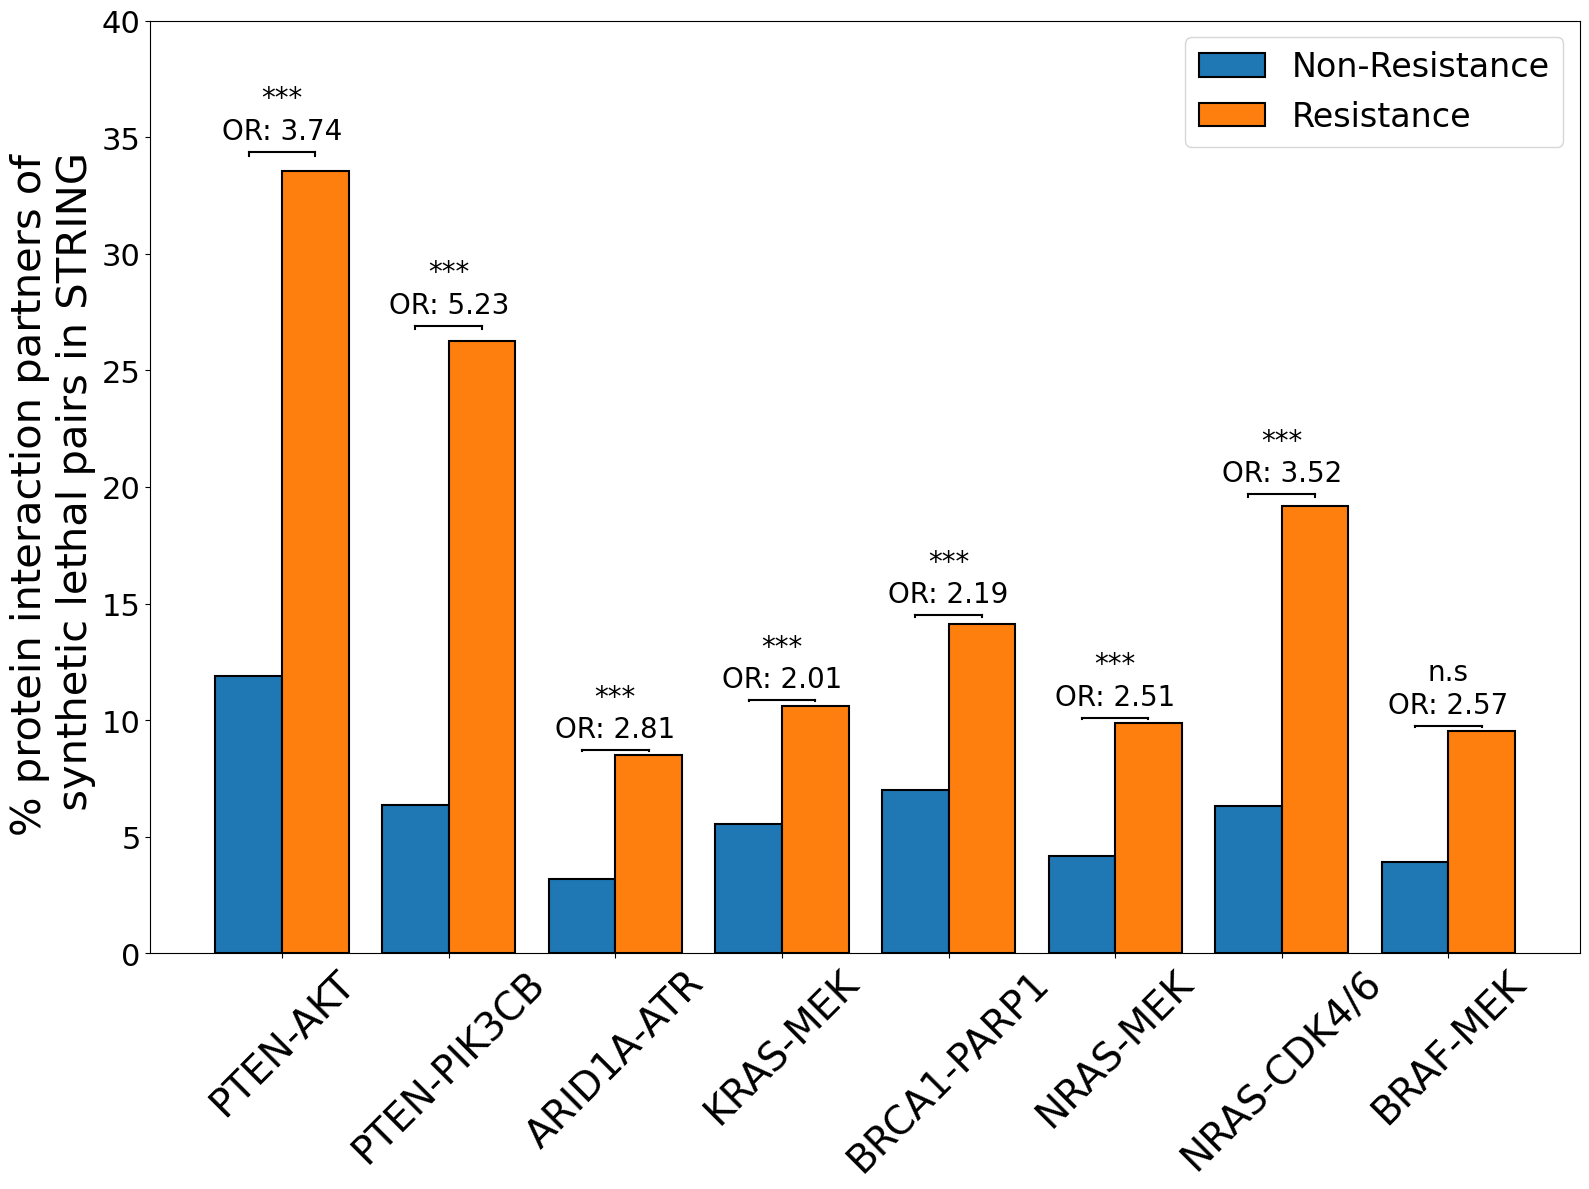

In [26]:
import matplotlib.pyplot as plt
all_results = pd.read_csv('results/3_interaction_overlap_graphs/all_results_seperate_screen_string.csv')
positions = range(len(all_results))
width = 0.4

plt.figure(figsize=(16, 12))  # Adjust figure size for better visibility

# Plot the bars with bold edges
bars1 = plt.bar(
    [p - width/2 for p in positions], 
    all_results['resistant_0_ratio'], 
    width=width, 
    label='Non-Resistance', 
    edgecolor='black', 
    linewidth=1.5
)
bars2 = plt.bar(
    [p + width/2 for p in positions], 
    all_results['resistant_1_ratio'], 
    width=width, 
    label='Resistance', 
    edgecolor='black', 
    linewidth=1.5
)

plt.ylim(0, 40)
plt.ylabel('% protein interaction partners of \n synthetic lethal pairs in STRING', fontsize=30)
plt.xticks(positions, all_results['Synthetic Lethal partners'], rotation=45, fontsize=28)
plt.yticks(fontsize=22)

p_values = all_results['p_value']
odds_ratios = all_results['odds_ratio']

# --- significance stars function ---
def significance_stars(pval):
    if pval < 0.001:
        return "***"
    elif pval < 0.01:
        return "**"
    elif pval < 0.05:
        return "*"
    else:
        return "n.s"   # no text if not significant

# Function to annotate with asterisks + OR
def annotate_p_value_and_odds_ratio(ax, bars1, bars2, p_values, odds_ratios):
    for idx, (bar1, bar2, p, odds_ratio) in enumerate(zip(bars1, bars2, p_values, odds_ratios)):
        height = max(bar1.get_height(), bar2.get_height())
        line_height = height + 0.02 * height
        bracket_height = 0.005 * height
        
        # Stars + OR text
        stars = significance_stars(p)
        if stars:  
            combined_text = f"{stars}\nOR: {odds_ratio:.2f}"
        else:
            combined_text = f"OR: {odds_ratio:.2f}"
        
        ax.plot([bar1.get_x() + bar1.get_width()/2, bar1.get_x() + bar1.get_width()/2],
                [line_height, line_height + bracket_height], lw=1.5, color='black')
        ax.plot([bar2.get_x() + bar2.get_width()/2, bar2.get_x() + bar2.get_width()/2],
                [line_height, line_height + bracket_height], lw=1.5, color='black')
        ax.plot([bar1.get_x() + bar1.get_width()/2, bar2.get_x() + bar2.get_width()/2],
                [line_height + bracket_height, line_height + bracket_height], lw=1.5, color='black')
        
        ax.annotate(combined_text, 
                    xy=((bar1.get_x() + bar2.get_x() + bar1.get_width())/2, line_height + bracket_height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=20)

annotate_p_value_and_odds_ratio(plt.gca(), bars1, bars2, p_values, odds_ratios)

plt.legend(fontsize=24)
plt.tight_layout()
plt.savefig('results/3_interaction_overlap_graphs/figure2a_string_all_screens_asterisk.jpg', dpi=600)
plt.show()


In [27]:
import pandas as pd
import glob
from scipy.stats import fisher_exact

# Function to process each file type
def process_count_files(file_pattern, synthetic_lethal_partners, study):
    files = glob.glob(file_pattern)  # Find all files matching the pattern
    results = []
    
    for file in files:
        df = pd.read_csv(file)
        
        if len(df) == 4:  # Type 1
            interacted_resistant = df['Interacted'][3] + df['Interacted'][2] + df['Interacted'][1]
            interacted_no_resistant = df['Interacted'][0]
            no_interacted_resistant = (df['Total'][3] + df['Total'][2] + df['Total'][1]) - interacted_resistant
            no_interacted_no_resistant = df['Total'][0] - df['Interacted'][0]
        elif len(df) == 3:  # Type 2
            interacted_resistant = df['Interacted'][2] + df['Interacted'][1]
            interacted_no_resistant = df['Interacted'][0]
            no_interacted_resistant = (df['Total'][2] + df['Total'][1]) - interacted_resistant
            no_interacted_no_resistant = df['Total'][0] - df['Interacted'][0]
        elif len(df) == 2:  # Type 3
            interacted_resistant = df['Interacted'][1]
            interacted_no_resistant = df['Interacted'][0]
            no_interacted_resistant = df['Total'][1] - interacted_resistant
            no_interacted_no_resistant = df['Total'][0] - df['Interacted'][0]
        else:
            print(f"Skipping file {file}, unexpected format.")
            continue
        
        # Compute Fisher's exact test
        contingency_table = [[interacted_resistant, interacted_no_resistant],
                             [no_interacted_resistant, no_interacted_no_resistant]]
        odds_ratio, p_value = fisher_exact(contingency_table)
        
        # Compute resistant percentages
        resistant_percentage = (interacted_resistant / (df['Total'].sum() - df['Total'][0])) * 100
        not_resistant_percentage = (interacted_no_resistant / df['Total'][0]) * 100
        
        results.append([synthetic_lethal_partners, study, file, interacted_resistant, interacted_no_resistant,
                        no_interacted_resistant, no_interacted_no_resistant,
                        p_value, odds_ratio, not_resistant_percentage, resistant_percentage])
    
    return results

# Process all file types
type1_results = process_count_files('results/2_interaction_overlap/biogrid_counts/dunn_PTEN_AKT_biogrid_count.csv','PTEN-AKT', 'Dunn')
type2_results = process_count_files('results/2_interaction_overlap/biogrid_counts/dunn_PTEN_PIK3CB_biogrid_count.csv','PTEN-PIK3CB', 'Dunn')
type3_results = process_count_files('results/2_interaction_overlap/biogrid_counts/ARID1A_ATR_Awwad_Llorca_aggregated_biogrid_count.csv','ARID1A-ATR', 'Awwad_Llorca')
type4_results = process_count_files('results/2_interaction_overlap/biogrid_counts/KRAS_MEK_Krall_Wang_Yu_aggregated_biogrid_count.csv','KRAS-MEK','Krall_Wang_Yu')
type5_results = process_count_files('results/2_interaction_overlap/biogrid_counts/BRCA1_PARP1_Noordermeer_Zimmermann_aggregated_biogrid_count.csv','BRCA1-PARP1','Noordermeer_Zimmermann')
type6_results = process_count_files('results/2_interaction_overlap/biogrid_counts/NRAS_MEK_Hayes_Krall_aggregated_biogrid_count.csv','NRAS-MEK','Hayes_Krall')
type7_results = process_count_files('results/2_interaction_overlap/biogrid_counts/hayes_NRAS_CDK4_6_biogrid_count.csv','NRAS-CDK4/6','Hayes')
type8_results = process_count_files('results/2_interaction_overlap/biogrid_counts/krall_BRAF_MEK_biogrid_count.csv','BRAF-MEK','Krall')

# Convert results to DataFrame
columns = ['Synthetic Lethal partners', 'Study', 'File', 'INT_and_RES', 'INT_and_NO_RES', 'No_INT_and_RES', 'NO_INT_NO_RES',
           'p_value', 'odds_ratio', 'resistant_0_ratio', 'resistant_1_ratio']
all_results_biogrid = pd.DataFrame(type1_results + type2_results + type3_results + 
                           type4_results + type5_results + type6_results + 
                           type7_results + type8_results, columns=columns)
all_results_biogrid = all_results_biogrid.drop('File',axis=1)
all_results_biogrid.to_csv('results/3_interaction_overlap_graphs/all_results_seperate_screen_biogrid.csv',index=False)
# Save to Excel
all_results_biogrid

,Synthetic Lethal partners,Study,INT_and_RES,INT_and_NO_RES,No_INT_and_RES,NO_INT_NO_RES,p_value,odds_ratio,resistant_0_ratio,resistant_1_ratio
0,PTEN-AKT,Dunn,17,295,147,17553,3.970860e-09,6.881148,1.652846,10.365854
1,PTEN-PIK3CB,Dunn,6,133,93,17778,1.179790e-04,8.623818,0.742560,6.060606
2,ARID1A-ATR,Awwad_Llorca,4,77,196,18562,1.086182e-02,4.919693,0.413112,2.000000
3,KRAS-MEK,Krall_Wang_Yu,7,420,389,17756,6.104119e-01,0.760754,2.310739,1.767677
4,BRCA1-PARP1,Noordermeer_Zimmermann,21,447,283,16252,1.107400e-04,2.697939,2.676807,6.907895
5,NRAS-MEK,Hayes_Krall,5,177,289,18127,2.164095e-01,1.771841,0.967002,1.700680
6,NRAS-CDK4/6,Hayes,4,174,121,15848,4.959244e-02,3.010924,1.086007,3.200000
7,BRAF-MEK,Krall,0,68,42,18789,1.000000e+00,0.000000,0.360609,0.000000


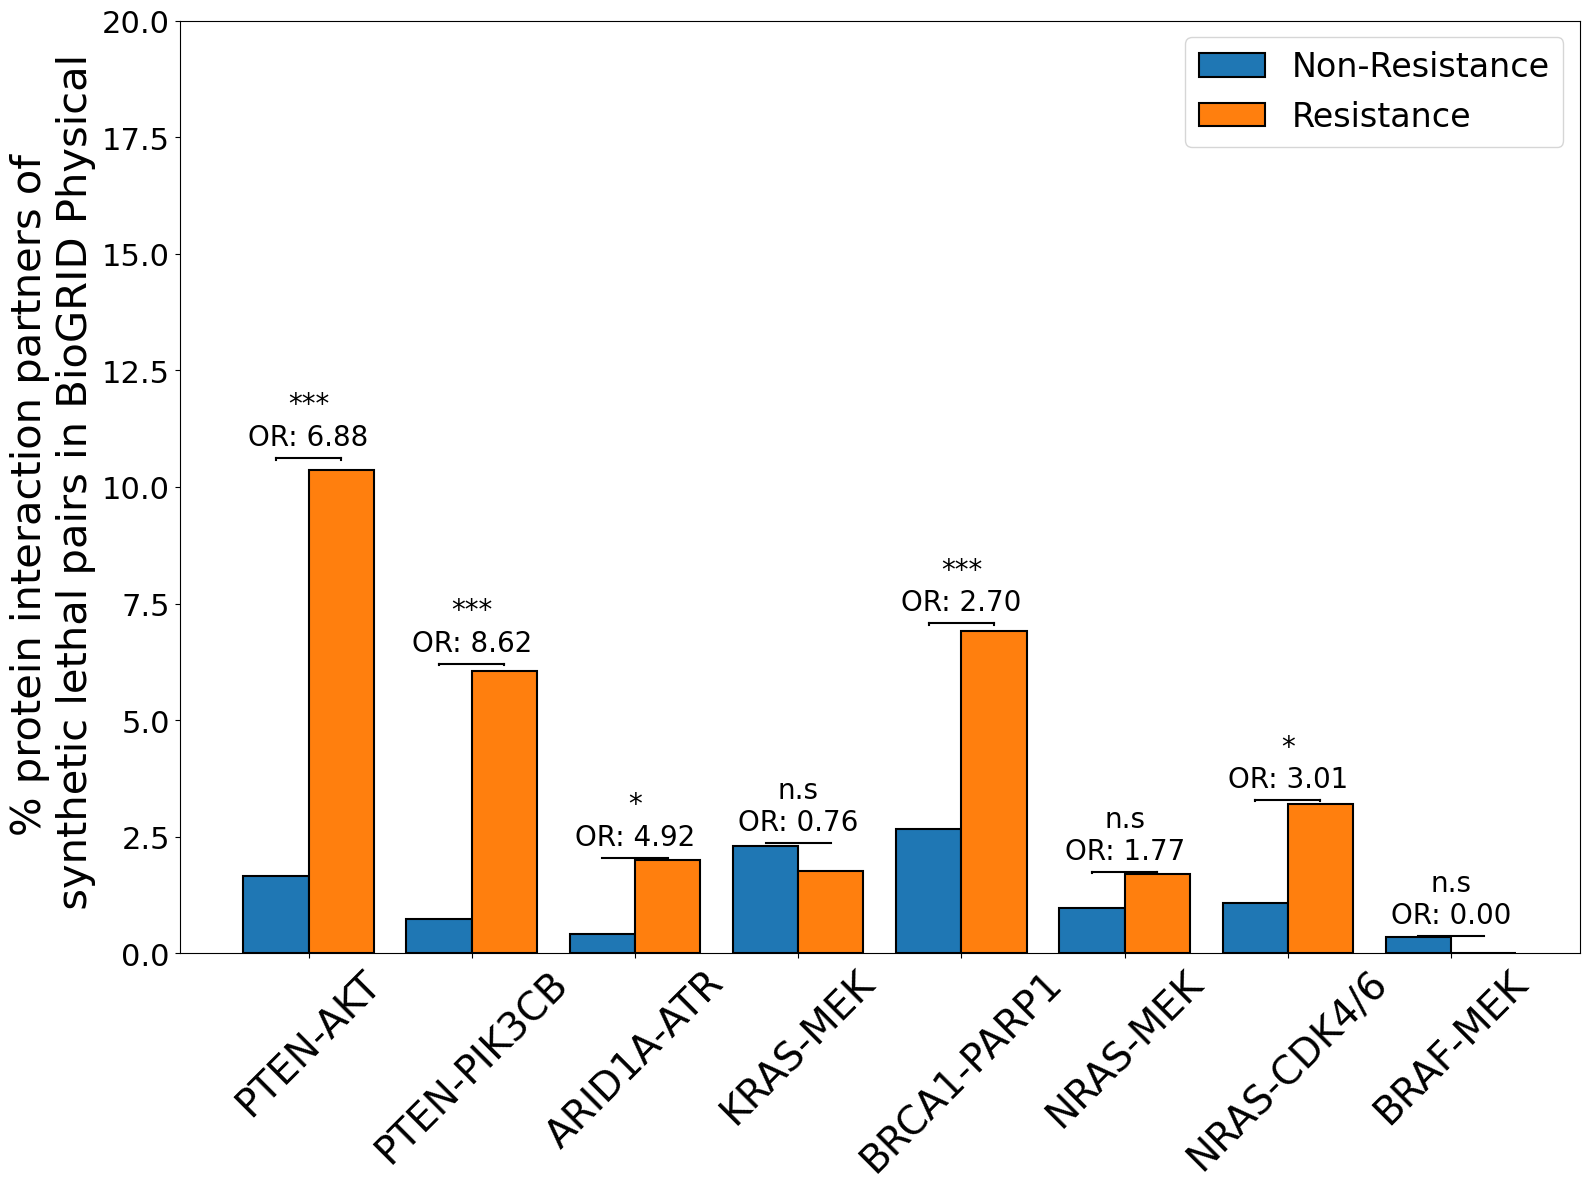

In [29]:
import matplotlib.pyplot as plt
all_results_biogrid = pd.read_csv('results/3_interaction_overlap_graphs/all_results_seperate_screen_biogrid.csv')
positions = range(len(all_results_biogrid))
width = 0.4

plt.figure(figsize=(16, 12))  # Adjust figure size for better visibility

# Plot the bars with bold edges
bars1 = plt.bar(
    [p - width/2 for p in positions], 
    all_results_biogrid['resistant_0_ratio'], 
    width=width, 
    label='Non-Resistance', 
    edgecolor='black', 
    linewidth=1.5
)
bars2 = plt.bar(
    [p + width/2 for p in positions], 
    all_results_biogrid['resistant_1_ratio'], 
    width=width, 
    label='Resistance', 
    edgecolor='black', 
    linewidth=1.5
)

plt.ylim(0, 20)
plt.ylabel('% protein interaction partners of \n synthetic lethal pairs in BioGRID Physical', fontsize=30)
plt.xticks(positions, all_results_biogrid['Synthetic Lethal partners'], rotation=45, fontsize=28)
plt.yticks(fontsize=22)

p_values = all_results_biogrid['p_value']
odds_ratios = all_results_biogrid['odds_ratio']

# --- significance stars function ---
def significance_stars(pval):
    if pval < 0.001:
        return "***"
    elif pval < 0.01:
        return "**"
    elif pval < 0.05:
        return "*"
    else:
        return "n.s"   # no text if not significant

# Function to annotate with asterisks + OR
def annotate_p_value_and_odds_ratio(ax, bars1, bars2, p_values, odds_ratios):
    for idx, (bar1, bar2, p, odds_ratio) in enumerate(zip(bars1, bars2, p_values, odds_ratios)):
        height = max(bar1.get_height(), bar2.get_height())
        line_height = height + 0.02 * height
        bracket_height = 0.005 * height
        
        # Stars + OR text
        stars = significance_stars(p)
        if stars:  
            combined_text = f"{stars}\nOR: {odds_ratio:.2f}"
        else:
            combined_text = f"OR: {odds_ratio:.2f}"
        
        ax.plot([bar1.get_x() + bar1.get_width()/2, bar1.get_x() + bar1.get_width()/2],
                [line_height, line_height + bracket_height], lw=1.5, color='black')
        ax.plot([bar2.get_x() + bar2.get_width()/2, bar2.get_x() + bar2.get_width()/2],
                [line_height, line_height + bracket_height], lw=1.5, color='black')
        ax.plot([bar1.get_x() + bar1.get_width()/2, bar2.get_x() + bar2.get_width()/2],
                [line_height + bracket_height, line_height + bracket_height], lw=1.5, color='black')
        
        ax.annotate(combined_text, 
                    xy=((bar1.get_x() + bar2.get_x() + bar1.get_width())/2, line_height + bracket_height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=20)

annotate_p_value_and_odds_ratio(plt.gca(), bars1, bars2, p_values, odds_ratios)

plt.legend(fontsize=24)
plt.tight_layout()
plt.savefig('results/3_interaction_overlap_graphs/supplementary_figure_1_biogrid_all_screens_asterisk.jpg', dpi=600)
plt.show()
